In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, Polygon
import ipywidgets as widgets
from IPython.display import display, clear_output
import lonboard as lb
from shapely.ops import unary_union, linemerge
import pandas as pd
import networkx as nx
from shapely.geometry import LineString
from shapely.geometry import MultiLineString, Point
from shapely.geometry import MultiPoint

In [ ]:
# Load the correct layer
gdf = gpd.read_file("denmark.gpkg", layer="gis_osm_roads_free") 

In [ ]:
def road_extractor(gdf):
    # Reproject everything to EPSG:4326 (WGS84) upfront for consistency.
    # lonboard also expects EPSG:4326, so this avoids downstream CRS issues.
    gdf = gdf.to_crs(epsg=4326)

    # Objective 1: Filter to only Secondary, Primary, Tertiary and residential roads
    target_fclasses = ["secondary", "primary", "tertiary", "residential"]
    gdf_filtered = gdf[gdf["fclass"].isin(target_fclasses)].copy()

    gdf_filtered = gdf_filtered[gdf_filtered["name"].notna() & (gdf_filtered["name"] != "")]
    return gdf_filtered.reset_index(drop=True)

gdf_merged = road_extractor(gdf)

In [ ]:
# save geodataframe to a a geojson file
gdf_merged.to_file("PSTR_roads.geojson", driver="GeoJSON")

In [2]:
# read the road network data
gdf_roadnetwork = gpd.read_file(r'd:\\Pipe_builder_gui\\PSTR_roads.geojson')

In [3]:
def extend_line(line, distance):
    """Extend a LineString by `distance` meters at both ends by extrapolating the end segments."""
    coords = list(line.coords)
    if len(coords) < 2:
        return line

    # Extend start: extrapolate backwards from coords[1] -> coords[0]
    x0, y0 = coords[0]
    x1, y1 = coords[1]
    dx, dy = x0 - x1, y0 - y1
    length = np.hypot(dx, dy)
    if length > 0:
        coords[0] = (x0 + distance * dx / length, y0 + distance * dy / length)

    # Extend end: extrapolate forwards from coords[-2] -> coords[-1]
    x0, y0 = coords[-2]
    x1, y1 = coords[-1]
    dx, dy = x1 - x0, y1 - y0
    length = np.hypot(dx, dy)
    if length > 0:
        coords[-1] = (x1 + distance * dx / length, y1 + distance * dy / length)

    return LineString(coords)


def merge_intersecting_segments(group):
    """
    Within a same-name group, build a graph where each segment is a node.
    Add an edge between two segments if they intersect or touch.
    Merge only the segments within each connected component.
    Returns a list of (row, merged_geometry) tuples — one per connected component.
    """
    geoms = list(group.geometry)
    n = len(geoms)

    G = nx.Graph()
    G.add_nodes_from(range(n))

    for i in range(n):
        for j in range(i + 1, n):
            if geoms[i].intersects(geoms[j]) or geoms[i].touches(geoms[j]):
                G.add_edge(i, j)

    rows = []
    for component in nx.connected_components(G):
        indices = list(component)
        merged_geom = unary_union([geoms[i] for i in indices])
        row = group.iloc[indices[0]].copy()
        row["geometry"] = merged_geom
        component_fclasses = group.iloc[indices]["fclass"].unique()
        row["fclass"] = ", ".join(sorted(component_fclasses))
        rows.append(row)

    return rows


def filtered_frame(gdf):
    # Drop rows with no name
    gdf = gdf[gdf["name"].notna() & (gdf["name"] != "")].copy()

    # Reproject to metric CRS (EPSG:3857) so 1 meter extension is accurate
    gdf_metric = gdf.to_crs(epsg=3857)

    # Explode MultiLineStrings into individual LineStrings
    gdf_exploded = gdf_metric.explode(index_parts=False).reset_index(drop=True)
    gdf_exploded = gdf_exploded[gdf_exploded.geometry.type == "LineString"].copy()

    # Extend each segment by x meter at both ends so near-touching segments overlap
    gdf_exploded["geometry"] = gdf_exploded.geometry.apply(lambda line: extend_line(line, 25.0))

    # For each name group, merge only connected (intersecting/touching) segments
    all_rows = []
    for name, group in gdf_exploded.groupby("name"):
        all_rows.extend(merge_intersecting_segments(group))

    gdf_merged = gpd.GeoDataFrame(all_rows, geometry="geometry", crs="EPSG:3857").reset_index(drop=True)

    # Reproject back to WGS84
    return gdf_merged.to_crs(epsg=4326)


In [4]:
roadnetwork_filtered = filtered_frame(gdf_roadnetwork)

roadnetwork_filtered.to_file(r'd:\\Pipe_builder_gui\\road_network_postproc.geojson', driver='GeoJSON')

In [ ]:
{ "type": "Feature", "properties": { "osm_id": "2960202", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 11.781458525385304, 55.441223516421189 ], [ 11.7819069, 55.441331 ], [ 11.7824692, 55.441455 ], [ 11.782722, 55.4415034 ], [ 11.7829986, 55.4415557 ], [ 11.7838019, 55.4416847 ], [ 11.7858471, 55.4419897 ], [ 11.7862394, 55.4420474 ], [ 11.7864969, 55.4420852 ], [ 11.787501, 55.4422388 ], [ 11.787791, 55.4422803 ], [ 11.7879075, 55.4422971 ], [ 11.788055, 55.442318299999982 ], [ 11.7883173, 55.4423597 ], [ 11.7885419, 55.442395 ], [ 11.78901189999991, 55.442461399999985 ] ], [ [ 11.78901189999991, 55.442461399999985 ], [ 11.789020616858284, 55.442462631487004 ] ], [ [ 11.789003198456086, 55.44246013414503 ], [ 11.78901189999991, 55.442461399999985 ] ], [ [ 11.78901189999991, 55.442461399999985 ], [ 11.7898306, 55.4425805 ], [ 11.7898663, 55.4425815 ], [ 11.789902, 55.4425824 ], [ 11.789969917654608, 55.442571061301969 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "4565214", "code": 5114, "fclass": "secondary", "name": "Jyllandsgade", "ref": "O1", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.930633461976331, 57.042571135360532 ], [ 9.930373299990247, 57.042561399999627 ] ], [ [ 9.930373299990247, 57.042561399999627 ], [ 9.930364338023669, 57.042561064639365 ] ], [ [ 9.928659583083874, 57.042536880850385 ], [ 9.928650600000539, 57.0425369 ] ], [ [ 9.928650600000539, 57.0425369 ], [ 9.9277124, 57.0425389 ], [ 9.9271956, 57.0425576 ], [ 9.9261606000127, 57.042561 ] ], [ [ 9.9261606000127, 57.042561 ], [ 9.926151617010932, 57.042561029509329 ] ], [ [ 9.923150982979449, 57.04254156963632 ], [ 9.923142000020059, 57.042541599999929 ] ], [ [ 9.923142000020059, 57.042541599999929 ], [ 9.922757399773486, 57.042542900000761 ] ], [ [ 9.922757399773486, 57.042542900000761 ], [ 9.922748417020552, 57.04254293036368 ] ], [ [ 9.922766382980345, 57.042542869715056 ], [ 9.922757399773486, 57.042542900000761 ] ], [ [ 9.922757399773486, 57.042542900000761 ], [ 9.9223718, 57.0425442 ], [ 9.9210244, 57.0425487 ], [ 9.9201993, 57.0425517 ], [ 9.919926500000152, 57.0425457 ] ], [ [ 9.919926500000152, 57.0425457 ], [ 9.919917524179741, 57.042545502584581 ] ], [ [ 9.918995878849339, 57.042539548748323 ], [ 9.918986899999874, 57.0425397 ] ], [ [ 9.918986899999874, 57.0425397 ], [ 9.918847321150659, 57.042542051251672 ] ], [ [ 9.929663380499388, 57.042538618772213 ], [ 9.929654399999926, 57.0425385 ] ], [ [ 9.929654399999926, 57.0425385 ], [ 9.9293822, 57.0425349 ], [ 9.928751, 57.0425365 ], [ 9.928650600000539, 57.0425369 ] ], [ [ 9.928650600000539, 57.0425369 ], [ 9.928641617088042, 57.042536935788497 ] ], [ [ 9.919935481073566, 57.042545805140961 ], [ 9.919926500000152, 57.0425457 ] ], [ [ 9.919926500000152, 57.0425457 ], [ 9.9196617, 57.0425426 ], [ 9.918986899999874, 57.0425397 ] ], [ [ 9.918986899999874, 57.0425397 ], [ 9.918977917127442, 57.04253966139548 ] ], [ [ 9.930382262125228, 57.042561734180921 ], [ 9.930373299990247, 57.042561399999627 ] ], [ [ 9.930373299990247, 57.042561399999627 ], [ 9.9303143, 57.0425592 ], [ 9.9301792, 57.0425542 ], [ 9.9300085, 57.0425502 ], [ 9.929654399999926, 57.0425385 ] ], [ [ 9.929654399999926, 57.0425385 ], [ 9.929645433370412, 57.042538203728938 ] ], [ [ 9.926169582997003, 57.042560971214485 ], [ 9.9261606000127, 57.042561 ] ], [ [ 9.9261606000127, 57.042561 ], [ 9.9256925, 57.0425625 ], [ 9.9256077, 57.0425628 ], [ 9.9255681, 57.042562899999986 ], [ 9.925282599997811, 57.042543799999841 ] ], [ [ 9.925282599997811, 57.042543799999841 ], [ 9.925273684011376, 57.042543203518633 ] ], [ [ 9.925157482993438, 57.042534870886954 ], [ 9.925148499999988, 57.0425349 ] ], [ [ 9.925148499999988, 57.0425349 ], [ 9.9248708, 57.0425358 ], [ 9.9246246, 57.0425366 ], [ 9.9244731, 57.0425372 ], [ 9.923142000020059, 57.042541599999929 ] ], [ [ 9.923142000020059, 57.042541599999929 ], [ 9.923133017012983, 57.042541629693595 ] ], [ [ 9.925291517040502, 57.042544391809464 ], [ 9.925282599997811, 57.042543799999841 ] ], [ [ 9.925282599997811, 57.042543799999841 ], [ 9.925148499999988, 57.0425349 ] ], [ [ 9.925148499999988, 57.0425349 ], [ 9.925139582959497, 57.042534308190376 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "23165188", "code": 5114, "fclass": "secondary", "name": "Jyllandsgade", "ref": "195", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.164344444839481, 56.140125587370704 ], [ 9.1643634, 56.1400004 ], [ 9.1643669, 56.1399772 ], [ 9.1644245, 56.1396193 ], [ 9.1644915, 56.1392036 ], [ 9.1645855, 56.1386522 ], [ 9.1646144, 56.1384859 ], [ 9.1647287, 56.1378871 ], [ 9.16484, 56.1373036 ], [ 9.1648633, 56.1371818 ], [ 9.164887, 56.1370503 ], [ 9.1650845, 56.1359562 ], [ 9.1652568, 56.135037 ], [ 9.1653621, 56.1344751 ], [ 9.1654163, 56.1340778 ], [ 9.1656268, 56.1330345 ], [ 9.1656545, 56.1328246 ], [ 9.1657215, 56.1325967 ], [ 9.1658634, 56.13233180000001 ] ], [ [ 9.1658634, 56.13233180000001 ], [ 9.165865969580125, 56.132327003071431 ] ], [ [ 9.166333754908322, 56.131750169908379 ], [ 9.16633780000004, 56.131745699999961 ] ], [ [ 9.16633780000004, 56.131745699999961 ], [ 9.1666025, 56.1314532 ], [ 9.1669364, 56.1310402 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.169629702200822, 56.128115945864444 ] ], [ [ 9.169622721482703, 56.128125142651008 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.1698075, 56.1278207 ], [ 9.169843779943914, 56.127760957573692 ] ], [ [ 9.170024488804598, 56.127806212992432 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.169620411195401, 56.128124486974173 ] ], [ [ 9.165860474526683, 56.132336533199336 ], [ 9.1658634, 56.13233180000001 ] ], [ [ 9.1658634, 56.13233180000001 ], [ 9.1660084, 56.1320972 ], [ 9.1660501, 56.13205 ], [ 9.166207099999982, 56.131895300000018 ] ], [ [ 9.166207099999982, 56.131895300000018 ], [ 9.166211522298553, 56.131890942477703 ] ], [ [ 9.166203167618415, 56.131899801018406 ], [ 9.166207099999982, 56.131895300000018 ] ], [ [ 9.166207099999982, 56.131895300000018 ], [ 9.16633780000004, 56.131745699999961 ] ], [ [ 9.16633780000004, 56.131745699999961 ], [ 9.166341732381587, 56.13174119896356 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "25477947", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.959478734456717, 57.58823607207006 ], [ 9.9595903, 57.5882901 ], [ 9.9603697, 57.5886665 ], [ 9.9606034, 57.5887763 ], [ 9.9609062, 57.5889248 ], [ 9.961076, 57.5889985 ], [ 9.9614188, 57.589166699999986 ], [ 9.9616907, 57.58930010000001 ], [ 9.961835499999957, 57.589371099999973 ] ], [ [ 9.961835499999957, 57.589371099999973 ], [ 9.961842128045378, 57.589374349936058 ] ], [ [ 9.96248815951189, 57.589686117222293 ], [ 9.962494899999887, 57.589689299999954 ] ], [ [ 9.962494899999887, 57.589689299999954 ], [ 9.9629623, 57.58991 ], [ 9.9633918, 57.5901588 ], [ 9.963487299995926, 57.590214134446839 ] ], [ [ 9.961828823971047, 57.589367878401873 ], [ 9.961835499999957, 57.589371099999973 ] ], [ [ 9.961835499999957, 57.589371099999973 ], [ 9.962494899999887, 57.589689299999954 ] ], [ [ 9.962494899999887, 57.589689299999954 ], [ 9.96250157602895, 57.589692521569653 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "600300757", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.135662970039311, 55.474834297574688 ], [ 9.135654199999982, 55.4748354 ] ], [ [ 9.135654199999982, 55.4748354 ], [ 9.1356009, 55.474842099999989 ], [ 9.1351626, 55.4748975 ], [ 9.1351164, 55.4749033 ], [ 9.1348415, 55.4749437 ], [ 9.134742161109196, 55.474976885261562 ] ], [ [ 9.136050670051315, 55.474774467520746 ], [ 9.136041999996085, 55.474775800000607 ] ], [ [ 9.136041999996085, 55.474775800000607 ], [ 9.135654199999982, 55.4748354 ] ], [ [ 9.135654199999982, 55.4748354 ], [ 9.135645529948683, 55.4748367324772 ] ], [ [ 9.137318770092662, 55.474579567600578 ], [ 9.1366262, 55.474686 ], [ 9.1364663, 55.4747106 ], [ 9.1362998, 55.4747362 ], [ 9.1362494, 55.4747439 ], [ 9.136041999996085, 55.474775800000607 ] ], [ [ 9.136041999996085, 55.474775800000607 ], [ 9.136033330417987, 55.474777133459746 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "28246562", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "B", "maxspeed": 0, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "LineString", "coordinates": [ [ 9.335040418268234, 55.066074308505264 ], [ 9.3351672, 55.0660756 ], [ 9.3355098, 55.0661022 ], [ 9.3359223, 55.0661374 ], [ 9.3360338, 55.0661469 ], [ 9.337415, 55.0662395 ], [ 9.3387563, 55.0663403 ], [ 9.3390625, 55.0663654 ], [ 9.3399824, 55.0664408 ], [ 9.340125, 55.0664508 ], [ 9.3419654, 55.0665814 ], [ 9.3424544, 55.0666193 ], [ 9.3429231, 55.0666556 ], [ 9.3429788, 55.0666599 ], [ 9.3439275, 55.0667333 ], [ 9.344017, 55.0667402 ], [ 9.344522701999697, 55.066779389868799 ] ] } },
{ "type": "Feature", "properties": { "osm_id": "52917978", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.71489785219582, 57.369877878119496 ], [ 9.7147877, 57.3698166 ], [ 9.7145753, 57.369698599999985 ] ], [ [ 9.7145753, 57.369698599999985 ], [ 9.714569043457059, 57.369695124137046 ] ], [ [ 9.714567027895535, 57.369696711255216 ], [ 9.7145753, 57.369698599999985 ] ], [ [ 9.7145753, 57.369698599999985 ], [ 9.7148556, 57.3697626 ], [ 9.7148957, 57.3697717 ], [ 9.715004272167317, 57.369796488659695 ] ], [ [ 9.714276301708033, 57.369553325596407 ], [ 9.714269599999886, 57.369550099999941 ] ], [ [ 9.714269599999886, 57.369550099999941 ], [ 9.7140315, 57.3694355 ], [ 9.7138102, 57.3693416 ], [ 9.7135127, 57.3692414 ], [ 9.7132518, 57.3691612 ], [ 9.713182, 57.3691397 ], [ 9.712603200000059, 57.368961800000015 ] ], [ [ 9.712603200000059, 57.368961800000015 ], [ 9.712595395649501, 57.36895940124851 ] ], [ [ 9.712168269315352, 57.368784371168452 ], [ 9.712162200000025, 57.36878080000001 ] ], [ [ 9.712162200000025, 57.36878080000001 ], [ 9.7120536, 57.3687169 ], [ 9.7117523, 57.3684998 ], [ 9.711675200000101, 57.368428100000102 ] ], [ [ 9.711675200000101, 57.368428100000102 ], [ 9.711670693884152, 57.368423909483269 ] ], [ [ 9.711679849377786, 57.368432244760221 ], [ 9.711675200000101, 57.368428100000102 ] ], [ [ 9.711675200000101, 57.368428100000102 ], [ 9.7115416, 57.368309 ], [ 9.7113751, 57.3681443 ], [ 9.711325706852142, 57.368095344925983 ] ], [ [ 9.712610753736602, 57.36896442166951 ], [ 9.712603200000059, 57.368961800000015 ] ], [ [ 9.712603200000059, 57.368961800000015 ], [ 9.7123848, 57.368886 ], [ 9.71227139999986, 57.368834 ] ], [ [ 9.71227139999986, 57.368834 ], [ 9.712264556694858, 57.368830861974118 ] ], [ [ 9.714581974202193, 57.369701842122915 ], [ 9.7145753, 57.369698599999985 ] ], [ [ 9.7145753, 57.369698599999985 ], [ 9.714269599999886, 57.369550099999941 ] ], [ [ 9.714269599999886, 57.369550099999941 ], [ 9.714262925797806, 57.369546857863668 ] ], [ [ 9.712278212350594, 57.368837157548676 ], [ 9.71227139999986, 57.368834 ] ], [ [ 9.71227139999986, 57.368834 ], [ 9.712244, 57.3688213 ], [ 9.712162200000025, 57.36878080000001 ] ], [ [ 9.712162200000025, 57.36878080000001 ], [ 9.712155583023936, 57.368777523866861 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "87574500", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.903193784092963, 56.834176028821602 ], [ 9.903039, 56.8341579 ], [ 9.9019634, 56.834034699999989 ], [ 9.9016199, 56.833999799999987 ], [ 9.9005158, 56.8339333 ], [ 9.898674, 56.8338379 ], [ 9.898261, 56.8338347 ], [ 9.8974452, 56.8338485 ], [ 9.8961421, 56.8338708 ], [ 9.8946557, 56.8338806 ], [ 9.8942655, 56.8338849 ], [ 9.8939824, 56.8338946 ], [ 9.8939255, 56.8338965 ], [ 9.8937246, 56.8339303 ], [ 9.8924443, 56.8342003 ], [ 9.8920796, 56.8342749 ], [ 9.8912936, 56.8344385 ], [ 9.890667, 56.8345689 ], [ 9.8904758, 56.8346055 ], [ 9.8900223, 56.8347026 ], [ 9.8897997, 56.8347303 ], [ 9.8896699, 56.8347325 ], [ 9.8895172, 56.834723 ], [ 9.8894651, 56.8347183 ], [ 9.889136, 56.8346699 ], [ 9.8888559, 56.8346287 ], [ 9.8885845, 56.8346031 ], [ 9.8885458, 56.8345995 ], [ 9.8883651, 56.834605 ], [ 9.8882237, 56.8346269 ], [ 9.8880238, 56.834669 ] ], [ [ 9.8880238, 56.834669 ], [ 9.888015416634511, 56.834670765580185 ] ], [ [ 9.888030883987749, 56.83466597807903 ], [ 9.8880238, 56.834669 ] ], [ [ 9.8880238, 56.834669 ], [ 9.8878297, 56.8347518 ], [ 9.887807, 56.8347611 ], [ 9.8876245, 56.8348355 ], [ 9.8873969, 56.834907 ], [ 9.887308958047816, 56.834950808719618 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1341232531", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.675263615944626, 56.787486850340748 ], [ 9.67527220004288, 56.787485399992754 ] ], [ [ 9.67527220004288, 56.787485399992754 ], [ 9.6761742, 56.787333 ], [ 9.6763523, 56.7873029 ], [ 9.6765639, 56.7872672 ], [ 9.676694000000323, 56.787244599999944 ] ], [ [ 9.676694000000323, 56.787244599999944 ], [ 9.676702562854748, 56.787243112524372 ] ], [ [ 9.679210695854493, 56.786825514197993 ], [ 9.679219299999742, 56.786824100000032 ] ], [ [ 9.679219299999742, 56.786824100000032 ], [ 9.6795448, 56.7867706 ], [ 9.6800774, 56.7866839 ], [ 9.6802948, 56.7866437 ], [ 9.6804933, 56.786607 ], [ 9.6809657, 56.7865318 ], [ 9.6813893, 56.7864908 ], [ 9.6818297, 56.7864481 ], [ 9.6820384, 56.7864327 ], [ 9.682643, 56.786377 ], [ 9.6831272, 56.7863312 ], [ 9.68372, 56.7862588 ] ], [ [ 9.68372, 56.7862588 ], [ 9.683728767855566, 56.786257729160987 ] ], [ [ 9.664494960965214, 56.789711560549542 ], [ 9.6644908, 56.7897072 ] ], [ [ 9.6644908, 56.7897072 ], [ 9.6640197, 56.78921350000001 ], [ 9.6638797, 56.7890818 ], [ 9.6637374, 56.7889702 ], [ 9.6636052, 56.7888719 ], [ 9.6633689, 56.7887557 ], [ 9.6627337, 56.7885294 ], [ 9.6625258, 56.7884263 ], [ 9.6622766, 56.7882452 ] ], [ [ 9.6622766, 56.7882452 ], [ 9.662271193132518, 56.788241270681716 ] ], [ [ 9.662282432015692, 56.788248942461387 ], [ 9.6622766, 56.7882452 ] ], [ [ 9.6622766, 56.7882452 ], [ 9.6620148, 56.788077199999982 ], [ 9.6619921, 56.7880626 ], [ 9.661890740538514, 56.787992135068031 ] ], [ [ 9.693083797387834, 56.782765087209434 ], [ 9.6929803, 56.7827905 ], [ 9.6929107, 56.7828128 ], [ 9.6928429, 56.7828387 ], [ 9.6927844, 56.7828658 ], [ 9.6925966, 56.78295760000001 ] ], [ [ 9.6925966, 56.78295760000001 ], [ 9.692589897300779, 56.782960876395158 ] ], [ [ 9.673605016095635, 56.787767050598035 ], [ 9.67361360003874, 56.787765599993449 ] ], [ [ 9.67361360003874, 56.787765599993449 ], [ 9.6743379, 56.7876432 ], [ 9.67527220004288, 56.787485399992754 ] ], [ [ 9.67527220004288, 56.787485399992754 ], [ 9.675280784323149, 56.787483950134785 ] ], [ [ 9.663659705744312, 56.789940779424967 ], [ 9.663704, 56.7898934 ], [ 9.6638147, 56.7898545 ], [ 9.6644908, 56.7897072 ] ], [ [ 9.6644908, 56.7897072 ], [ 9.6704797, 56.7883639 ], [ 9.6719465, 56.7880622 ], [ 9.6729292, 56.7878812 ], [ 9.67361360003874, 56.787765599993449 ] ], [ [ 9.67361360003874, 56.787765599993449 ], [ 9.673622184271348, 56.787764150053597 ] ], [ [ 9.6884695585409, 56.78506659331326 ], [ 9.688477600000263, 56.785064399999932 ] ], [ [ 9.688477600000263, 56.785064399999932 ], [ 9.68886, 56.7849601 ], [ 9.6897975, 56.7847045 ], [ 9.690172099999982, 56.7845857 ] ], [ [ 9.690172099999982, 56.7845857 ], [ 9.690179874267811, 56.784583234478099 ] ], [ [ 9.690164967039919, 56.784588691240891 ], [ 9.690172099999982, 56.7845857 ] ], [ [ 9.690172099999982, 56.7845857 ], [ 9.6901907, 56.7845779 ], [ 9.6903709, 56.7845126 ], [ 9.6905511, 56.7844351 ], [ 9.6907329, 56.7843484 ], [ 9.6908677, 56.7842753 ], [ 9.690965, 56.7842187 ], [ 9.691055, 56.7841608 ], [ 9.6911857, 56.7840725 ], [ 9.691261, 56.7840168 ], [ 9.6913288, 56.7839652 ], [ 9.6914202, 56.7838899 ], [ 9.6916488, 56.7836573 ], [ 9.6917291, 56.7835831 ], [ 9.6918758, 56.7834704 ], [ 9.6920967, 56.7833185 ], [ 9.6922556, 56.783204 ], [ 9.6925966, 56.78295760000001 ] ], [ [ 9.6925966, 56.78295760000001 ], [ 9.692602027067803, 56.782953678492774 ] ], [ [ 9.683711447624889, 56.786260305495404 ], [ 9.68372, 56.7862588 ] ], [ [ 9.68372, 56.7862588 ], [ 9.6838677, 56.7862328 ], [ 9.6846456, 56.786082 ], [ 9.6853119, 56.7859095 ], [ 9.6859673, 56.7857345 ], [ 9.6862687, 56.7856541 ], [ 9.6864623, 56.7856024 ], [ 9.6867891, 56.7855152 ], [ 9.687176, 56.7854119 ], [ 9.6875751, 56.7853053 ], [ 9.687884, 56.7852229 ], [ 9.688477600000263, 56.785064399999932 ] ], [ [ 9.688477600000263, 56.785064399999932 ], [ 9.688485674906749, 56.785062243875572 ] ], [ [ 9.676685414095502, 56.787246047062389 ], [ 9.676694000000323, 56.787244599999944 ] ], [ [ 9.676694000000323, 56.787244599999944 ], [ 9.6767385, 56.7872371 ], [ 9.6770267, 56.7871885 ], [ 9.6782255, 56.7869865 ], [ 9.6784052, 56.7869561 ], [ 9.6784856, 56.7869432 ], [ 9.6785627, 56.786931 ], [ 9.6790047, 56.7868586 ], [ 9.679219299999742, 56.786824100000032 ] ], [ [ 9.679219299999742, 56.786824100000032 ], [ 9.679227919575178, 56.78682271428012 ] ], [ [ 9.69259244026839, 56.782961961687327 ], [ 9.6925966, 56.78295760000001 ] ], [ [ 9.6925966, 56.78295760000001 ], [ 9.692714, 56.7828345 ], [ 9.6927416, 56.7827982 ], [ 9.6927659, 56.7827594 ], [ 9.6927806, 56.782725 ], [ 9.692811620378162, 56.782642880979928 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1421727360", "code": 5114, "fclass": "secondary", "name": "Jyllandsgade", "ref": "185", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.174361314305187, 56.121948782869133 ], [ 9.1743583, 56.121953499999989 ] ], [ [ 9.1743583, 56.121953499999989 ], [ 9.174106400000015, 56.12234769999997 ] ], [ [ 9.174106400000015, 56.12234769999997 ], [ 9.17410338569481, 56.122352417081949 ] ], [ [ 9.172742347027906, 56.12424293138676 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1721909, 56.1250358 ], [ 9.1718379, 56.125538 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.170527349414652, 56.127127749514102 ] ], [ [ 9.172737399818855, 56.124252516655929 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1728029, 56.1240631 ], [ 9.173298, 56.1232899 ], [ 9.1733584, 56.1232061 ], [ 9.1734399, 56.1230937 ], [ 9.1735482, 56.1229443 ], [ 9.173600600000036, 56.122872 ] ], [ [ 9.173600600000036, 56.122872 ], [ 9.173603964886421, 56.122867357222681 ] ], [ [ 9.173748437657379, 56.122893097303759 ], [ 9.1737449, 56.122897700000017 ] ], [ [ 9.1737449, 56.122897700000017 ], [ 9.1736881, 56.1229716 ], [ 9.1734974, 56.12323580000001 ], [ 9.1734441, 56.1233192 ], [ 9.1732771, 56.1235538 ], [ 9.1729054, 56.1240758 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1727348344156, 56.124252006648952 ] ], [ [ 9.174109347192831, 56.122342969758662 ], [ 9.174106400000015, 56.12234769999997 ] ], [ [ 9.174106400000015, 56.12234769999997 ], [ 9.1739502, 56.1225984 ], [ 9.1737449, 56.122897700000017 ] ], [ [ 9.1737449, 56.122897700000017 ], [ 9.173741691799801, 56.122902377109249 ] ], [ [ 9.175305531768711, 56.120653372192216 ], [ 9.1750364, 56.1210163 ], [ 9.1746823, 56.121565 ], [ 9.1745378, 56.1217525 ], [ 9.1744852, 56.1218207 ], [ 9.1743583, 56.121953499999989 ] ], [ [ 9.1743583, 56.121953499999989 ], [ 9.174354076773845, 56.121957919570001 ] ], [ [ 9.173597402621519, 56.122876679414311 ], [ 9.173600600000036, 56.122872 ] ], [ [ 9.173600600000036, 56.122872 ], [ 9.1742711, 56.1218907 ], [ 9.1744745, 56.12155760000001 ], [ 9.1751127, 56.1206642 ], [ 9.175147721837881, 56.120615147328202 ] ], [ [ 9.170534143834711, 56.127118489397972 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.1703388, 56.1274208 ], [ 9.1703334, 56.1274334 ], [ 9.17030128728083, 56.127507366291809 ] ], [ [ 9.170128542067935, 56.127451537693872 ], [ 9.1702089, 56.1273858 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.170536170806102, 56.127119067168536 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "363050275", "code": 5114, "fclass": "secondary", "name": "Jyllandsgade", "ref": "O1", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.919983416980788, 57.04243922665583 ], [ 9.919992399999526, 57.0424392 ] ], [ [ 9.919992399999526, 57.0424392 ], [ 9.9201946, 57.0424386 ], [ 9.9210425, 57.0424352 ], [ 9.9218989, 57.0424319 ], [ 9.922666, 57.0424289 ], [ 9.9231635, 57.042424 ], [ 9.924868099990013, 57.042420100000022 ] ], [ [ 9.924868099990013, 57.042420100000022 ], [ 9.924877083073397, 57.042420079447375 ] ], [ [ 9.924859116917769, 57.042420119376793 ], [ 9.924868099990013, 57.042420100000022 ] ], [ [ 9.924868099990013, 57.042420100000022 ], [ 9.92509989999998, 57.0424196 ] ], [ [ 9.92509989999998, 57.0424196 ], [ 9.925108883082228, 57.042419580623211 ] ], [ [ 9.930492117403428, 57.042367654385032 ], [ 9.930501100004522, 57.042367599999956 ] ], [ [ 9.930501100004522, 57.042367599999956 ], [ 9.930708282596573, 57.042366345614951 ] ], [ [ 9.929396145327996, 57.042395088843456 ], [ 9.929405100000018, 57.0423947 ] ], [ [ 9.929405100000018, 57.0423947 ], [ 9.9297229, 57.0423809 ], [ 9.9300748, 57.0423714 ], [ 9.930186699999858, 57.04236920000001 ] ], [ [ 9.930186699999858, 57.04236920000001 ], [ 9.930195677292389, 57.042369023502737 ] ], [ [ 9.925230819725156, 57.042417023695236 ], [ 9.925239800000154, 57.0424169 ] ], [ [ 9.925239800000154, 57.0424169 ], [ 9.9255665, 57.042412400000011 ], [ 9.925791099996804, 57.0424117 ] ], [ [ 9.925791099996804, 57.0424117 ], [ 9.925800083005425, 57.042411672003098 ] ], [ [ 9.919856816998658, 57.042438771617682 ], [ 9.91986580000003, 57.0424388 ] ], [ [ 9.91986580000003, 57.0424388 ], [ 9.919992399999526, 57.0424392 ] ], [ [ 9.919992399999526, 57.0424392 ], [ 9.920001383001342, 57.042439228382307 ] ], [ [ 9.930177717216873, 57.042369244337536 ], [ 9.930186699999858, 57.04236920000001 ] ], [ [ 9.930186699999858, 57.04236920000001 ], [ 9.9303893, 57.0423682 ], [ 9.930501100004522, 57.042367599999956 ] ], [ [ 9.930501100004522, 57.042367599999956 ], [ 9.930510082715763, 57.042367551792211 ] ], [ [ 9.918834919292042, 57.04244941400971 ], [ 9.919119600000357, 57.0424458 ] ], [ [ 9.919119600000357, 57.0424458 ], [ 9.919128580707959, 57.042445685990288 ] ], [ [ 9.925782117015421, 57.042411729911237 ], [ 9.925791099996804, 57.0424117 ] ], [ [ 9.925791099996804, 57.0424117 ], [ 9.926632, 57.0424089 ], [ 9.9275488, 57.0424066 ], [ 9.9276254, 57.04240570000001 ], [ 9.9288497, 57.042401 ], [ 9.9291019, 57.0424008 ], [ 9.929405100000018, 57.0423947 ] ], [ [ 9.929405100000018, 57.0423947 ], [ 9.929414077016238, 57.042394519393788 ] ], [ [ 9.92509092249464, 57.042419773261358 ], [ 9.92509989999998, 57.0424196 ] ], [ [ 9.92509989999998, 57.0424196 ], [ 9.925239800000154, 57.0424169 ] ], [ [ 9.925239800000154, 57.0424169 ], [ 9.925248777505361, 57.04241672673863 ] ], [ [ 9.919110617770693, 57.042445870074125 ], [ 9.919119600000357, 57.0424458 ] ], [ [ 9.919119600000357, 57.0424458 ], [ 9.9195426, 57.0424425 ], [ 9.9196597, 57.0424409 ], [ 9.91986580000003, 57.0424388 ] ], [ [ 9.91986580000003, 57.0424388 ], [ 9.91987478157762, 57.042438708484653 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "192296575", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.968027066461012, 57.591506775189892 ], [ 9.968019200000018, 57.591509099999989 ] ], [ [ 9.968019200000018, 57.591509099999989 ], [ 9.9677908, 57.5915766 ], [ 9.9674951, 57.591633 ], [ 9.9672932, 57.591656 ], [ 9.9671115, 57.5916603 ], [ 9.9668475, 57.5916464 ] ], [ [ 9.9668475, 57.5916464 ], [ 9.966838559884218, 57.591645929289271 ] ], [ [ 9.966451597094784, 57.591565951542634 ], [ 9.966444500000019, 57.591563 ] ], [ [ 9.966444500000019, 57.591563 ], [ 9.9661687, 57.5914483 ], [ 9.9652633, 57.591013199999985 ], [ 9.9643797, 57.5905886 ], [ 9.9639344, 57.5904218 ], [ 9.963807839567608, 57.590374339836039 ] ], [ [ 9.96643679985514, 57.591560520404585 ], [ 9.966444500000019, 57.591563 ] ], [ [ 9.966444500000019, 57.591563 ], [ 9.9665594, 57.5916 ], [ 9.9666716, 57.591624 ], [ 9.9668475, 57.5916464 ] ], [ [ 9.9668475, 57.5916464 ], [ 9.966856239828926, 57.591647512973886 ] ], [ [ 9.970626770888988, 57.590454600055295 ], [ 9.968019200000018, 57.591509099999989 ] ], [ [ 9.968019200000018, 57.591509099999989 ], [ 9.96801202911101, 57.591511999860622 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1287096649", "code": 5115, "fclass": "tertiary", "name": "Jyllandsgade", "ref": "", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "LineString", "coordinates": [ [ 11.790012435845723, 55.442658218995263 ], [ 11.7898988, 55.4426464 ], [ 11.7898635, 55.4426414 ], [ 11.7898282, 55.4426364 ], [ 11.7891241, 55.4425263 ], [ 11.7889888, 55.4425087 ], [ 11.7885141, 55.4424384 ], [ 11.7883061, 55.44240940000001 ], [ 11.7880286, 55.4423721 ], [ 11.7878831, 55.4423526 ], [ 11.7874745, 55.4422912 ], [ 11.7871805, 55.442247 ], [ 11.7865391, 55.442148 ], [ 11.7864311, 55.442129799999982 ], [ 11.7862199, 55.4420961 ], [ 11.7859857, 55.4420611 ], [ 11.7858233, 55.4420368 ], [ 11.784774, 55.4418821 ], [ 11.7837588, 55.4417306 ], [ 11.7829626, 55.4416017 ], [ 11.782697, 55.4415506 ], [ 11.7821498, 55.4414427 ], [ 11.7816555, 55.441337 ], [ 11.781606, 55.4413268 ], [ 11.7813384, 55.4412719 ], [ 11.7812195, 55.4412475 ], [ 11.7810809, 55.4412057 ], [ 11.780941, 55.4411471 ], [ 11.7809083, 55.4411334 ], [ 11.7807869, 55.4410604 ], [ 11.780743476732891, 55.440979726376234 ] ] } },




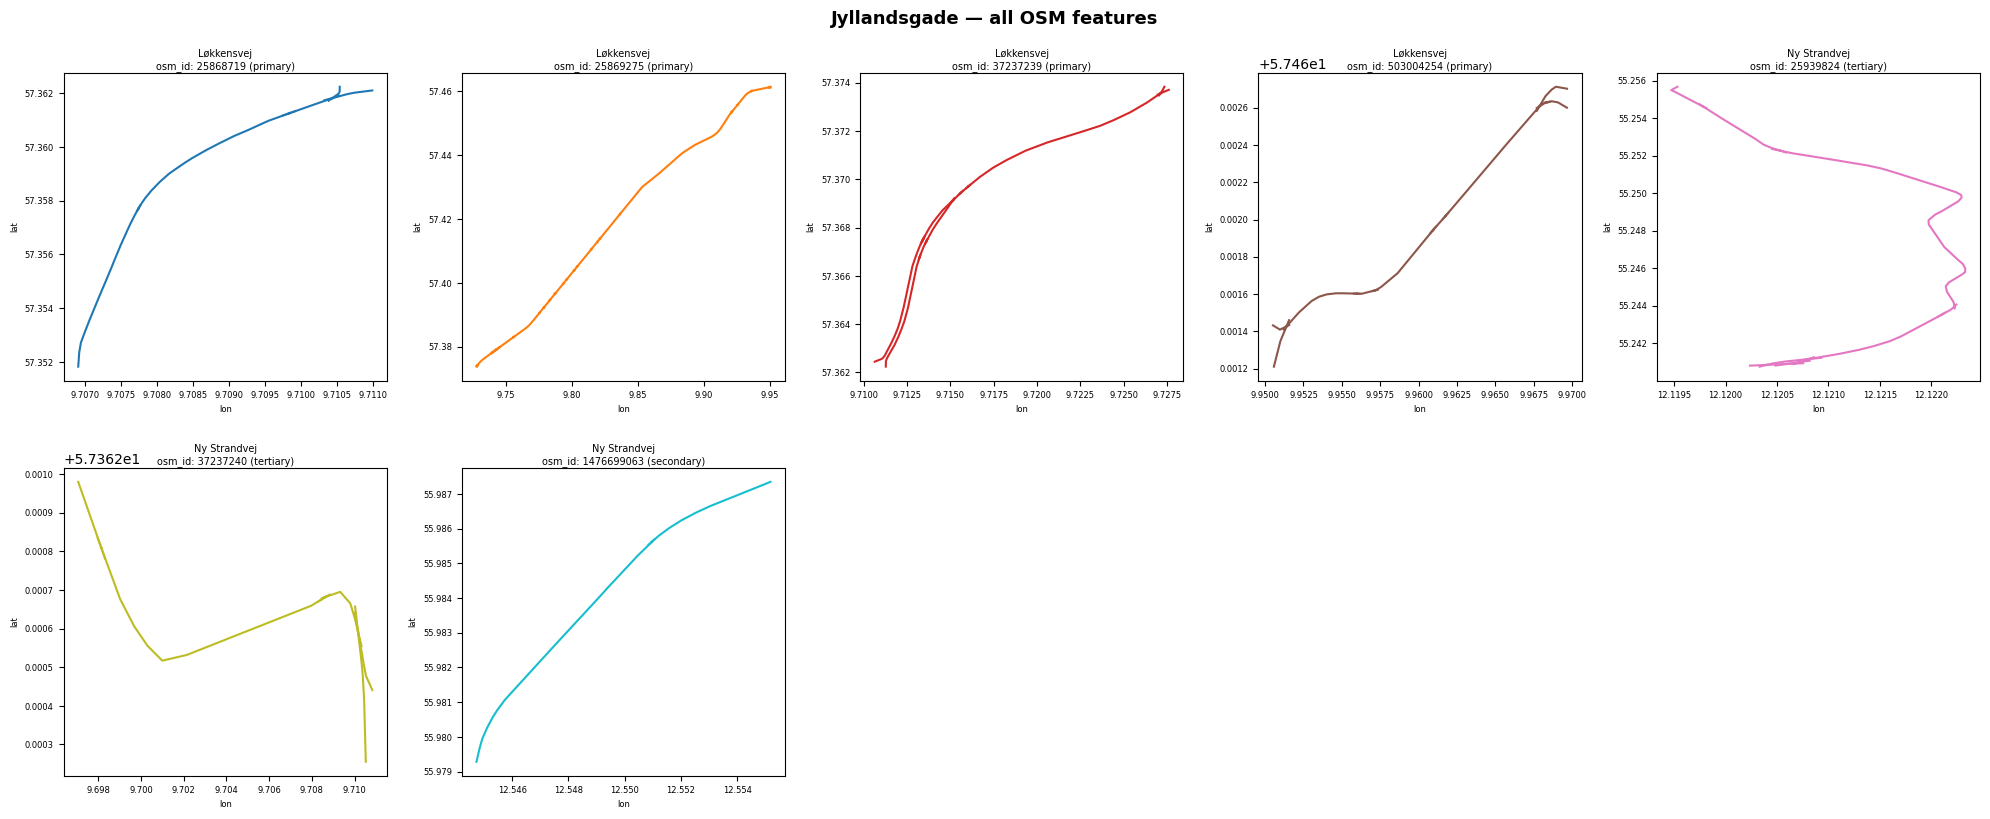

In [37]:
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

features_json = '''[
{ "type": "Feature", "properties": { "osm_id": "2960202", "fclass": "tertiary", "name": "Jyllandsgade" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 11.781458525385304, 55.441223516421189 ], [ 11.7819069, 55.441331 ], [ 11.7824692, 55.441455 ], [ 11.782722, 55.4415034 ], [ 11.7829986, 55.4415557 ], [ 11.7838019, 55.4416847 ], [ 11.7858471, 55.4419897 ], [ 11.7862394, 55.4420474 ], [ 11.7864969, 55.4420852 ], [ 11.787501, 55.4422388 ], [ 11.787791, 55.4422803 ], [ 11.7879075, 55.4422971 ], [ 11.788055, 55.442318299999982 ], [ 11.7883173, 55.4423597 ], [ 11.7885419, 55.442395 ], [ 11.78901189999991, 55.442461399999985 ] ], [ [ 11.78901189999991, 55.442461399999985 ], [ 11.789020616858284, 55.442462631487004 ] ], [ [ 11.789003198456086, 55.44246013414503 ], [ 11.78901189999991, 55.442461399999985 ] ], [ [ 11.78901189999991, 55.442461399999985 ], [ 11.7898306, 55.4425805 ], [ 11.7898663, 55.4425815 ], [ 11.789902, 55.4425824 ], [ 11.789969917654608, 55.442571061301969 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1287096649", "fclass": "tertiary", "name": "Jyllandsgade" }, "geometry": { "type": "LineString", "coordinates": [ [ 11.790012435845723, 55.442658218995263 ], [ 11.7898988, 55.4426464 ], [ 11.7898635, 55.4426414 ], [ 11.7898282, 55.4426364 ], [ 11.7891241, 55.4425263 ], [ 11.7889888, 55.4425087 ], [ 11.7885141, 55.4424384 ], [ 11.7883061, 55.44240940000001 ], [ 11.7880286, 55.4423721 ], [ 11.7878831, 55.4423526 ], [ 11.7874745, 55.4422912 ], [ 11.7871805, 55.442247 ], [ 11.7865391, 55.442148 ], [ 11.7864311, 55.442129799999982 ], [ 11.7862199, 55.4420961 ], [ 11.7859857, 55.4420611 ], [ 11.7858233, 55.4420368 ], [ 11.784774, 55.4418821 ], [ 11.7837588, 55.4417306 ], [ 11.7829626, 55.4416017 ], [ 11.782697, 55.4415506 ], [ 11.7821498, 55.4414427 ], [ 11.7816555, 55.441337 ], [ 11.781606, 55.4413268 ], [ 11.7813384, 55.4412719 ], [ 11.7812195, 55.4412475 ], [ 11.7810809, 55.4412057 ], [ 11.780941, 55.4411471 ], [ 11.7809083, 55.4411334 ], [ 11.7807869, 55.4410604 ], [ 11.780743476732891, 55.440979726376234 ] ] } },
{ "type": "Feature", "properties": { "osm_id": "4565214", "fclass": "secondary", "name": "Jyllandsgade (Aalborg)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.930633461976331, 57.042571135360532 ], [ 9.930373299990247, 57.042561399999627 ] ], [ [ 9.930373299990247, 57.042561399999627 ], [ 9.9303143, 57.0425592 ], [ 9.9301792, 57.0425542 ], [ 9.9300085, 57.0425502 ], [ 9.929654399999926, 57.0425385 ] ], [ [ 9.929654399999926, 57.0425385 ], [ 9.9293822, 57.0425349 ], [ 9.928751, 57.0425365 ], [ 9.928650600000539, 57.0425369 ] ], [ [ 9.928650600000539, 57.0425369 ], [ 9.9277124, 57.0425389 ], [ 9.9271956, 57.0425576 ], [ 9.9261606000127, 57.042561 ] ], [ [ 9.9261606000127, 57.042561 ], [ 9.9256925, 57.0425625 ], [ 9.9256077, 57.0425628 ], [ 9.9255681, 57.042562899999986 ], [ 9.925282599997811, 57.042543799999841 ] ], [ [ 9.925282599997811, 57.042543799999841 ], [ 9.925148499999988, 57.0425349 ] ], [ [ 9.925148499999988, 57.0425349 ], [ 9.9248708, 57.0425358 ], [ 9.9246246, 57.0425366 ], [ 9.9244731, 57.0425372 ], [ 9.923142000020059, 57.042541599999929 ] ], [ [ 9.923142000020059, 57.042541599999929 ], [ 9.922757399773486, 57.042542900000761 ] ], [ [ 9.922757399773486, 57.042542900000761 ], [ 9.9223718, 57.0425442 ], [ 9.9210244, 57.0425487 ], [ 9.9201993, 57.0425517 ], [ 9.919926500000152, 57.0425457 ] ], [ [ 9.919926500000152, 57.0425457 ], [ 9.9196617, 57.0425426 ], [ 9.918986899999874, 57.0425397 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "363050275", "fclass": "secondary", "name": "Jyllandsgade (Aalborg O1)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.919992399999526, 57.0424392 ], [ 9.9201946, 57.0424386 ], [ 9.9210425, 57.0424352 ], [ 9.9218989, 57.0424319 ], [ 9.922666, 57.0424289 ], [ 9.9231635, 57.042424 ], [ 9.924868099990013, 57.042420100000022 ] ], [ [ 9.924868099990013, 57.042420100000022 ], [ 9.92509989999998, 57.0424196 ] ], [ [ 9.92509989999998, 57.0424196 ], [ 9.925239800000154, 57.0424169 ] ], [ [ 9.925239800000154, 57.0424169 ], [ 9.9255665, 57.042412400000011 ], [ 9.925791099996804, 57.0424117 ] ], [ [ 9.925791099996804, 57.0424117 ], [ 9.926632, 57.0424089 ], [ 9.9275488, 57.0424066 ], [ 9.9276254, 57.04240570000001 ], [ 9.9288497, 57.042401 ], [ 9.9291019, 57.0424008 ], [ 9.929405100000018, 57.0423947 ] ], [ [ 9.929405100000018, 57.0423947 ], [ 9.9297229, 57.0423809 ], [ 9.9300748, 57.0423714 ], [ 9.930186699999858, 57.04236920000001 ] ], [ [ 9.930186699999858, 57.04236920000001 ], [ 9.9303893, 57.0423682 ], [ 9.930501100004522, 57.042367599999956 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "23165188", "fclass": "secondary", "name": "Jyllandsgade (Silkeborg)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.164344444839481, 56.140125587370704 ], [ 9.1643634, 56.1400004 ], [ 9.1643669, 56.1399772 ], [ 9.1644245, 56.1396193 ], [ 9.1644915, 56.1392036 ], [ 9.1645855, 56.1386522 ], [ 9.1646144, 56.1384859 ], [ 9.1647287, 56.1378871 ], [ 9.16484, 56.1373036 ], [ 9.1648633, 56.1371818 ], [ 9.164887, 56.1370503 ], [ 9.1650845, 56.1359562 ], [ 9.1652568, 56.135037 ], [ 9.1653621, 56.1344751 ], [ 9.1654163, 56.1340778 ], [ 9.1656268, 56.1330345 ], [ 9.1656545, 56.1328246 ], [ 9.1657215, 56.1325967 ], [ 9.1658634, 56.13233180000001 ] ], [ [ 9.1658634, 56.13233180000001 ], [ 9.1660084, 56.1320972 ], [ 9.1660501, 56.13205 ], [ 9.166207099999982, 56.131895300000018 ] ], [ [ 9.166207099999982, 56.131895300000018 ], [ 9.16633780000004, 56.131745699999961 ] ], [ [ 9.16633780000004, 56.131745699999961 ], [ 9.1666025, 56.1314532 ], [ 9.1669364, 56.1310402 ], [ 9.1696256, 56.1281204 ] ], [ [ 9.1696256, 56.1281204 ], [ 9.1698075, 56.1278207 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "25477947", "fclass": "tertiary", "name": "Jyllandsgade (Hjørring)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.959478734456717, 57.58823607207006 ], [ 9.9595903, 57.5882901 ], [ 9.9603697, 57.5886665 ], [ 9.9606034, 57.5887763 ], [ 9.9609062, 57.5889248 ], [ 9.961076, 57.5889985 ], [ 9.9614188, 57.589166699999986 ], [ 9.9616907, 57.58930010000001 ], [ 9.961835499999957, 57.589371099999973 ] ], [ [ 9.961835499999957, 57.589371099999973 ], [ 9.962494899999887, 57.589689299999954 ] ], [ [ 9.962494899999887, 57.589689299999954 ], [ 9.9629623, 57.58991 ], [ 9.9633918, 57.5901588 ], [ 9.963487299995926, 57.590214134446839 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "192296575", "fclass": "tertiary", "name": "Jyllandsgade (Hjørring 2)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.970626770888988, 57.590454600055295 ], [ 9.968019200000018, 57.591509099999989 ] ], [ [ 9.968019200000018, 57.591509099999989 ], [ 9.9677908, 57.5915766 ], [ 9.9674951, 57.591633 ], [ 9.9672932, 57.591656 ], [ 9.9671115, 57.5916603 ], [ 9.9668475, 57.5916464 ] ], [ [ 9.9668475, 57.5916464 ], [ 9.966444500000019, 57.591563 ] ], [ [ 9.966444500000019, 57.591563 ], [ 9.9661687, 57.5914483 ], [ 9.9652633, 57.591013199999985 ], [ 9.9643797, 57.5905886 ], [ 9.9639344, 57.5904218 ], [ 9.963807839567608, 57.590374339836039 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "28246562", "fclass": "tertiary", "name": "Jyllandsgade (Haderslev)" }, "geometry": { "type": "LineString", "coordinates": [ [ 9.335040418268234, 55.066074308505264 ], [ 9.3351672, 55.0660756 ], [ 9.3355098, 55.0661022 ], [ 9.3359223, 55.0661374 ], [ 9.3360338, 55.0661469 ], [ 9.337415, 55.0662395 ], [ 9.3387563, 55.0663403 ], [ 9.3390625, 55.0663654 ], [ 9.3399824, 55.0664408 ], [ 9.340125, 55.0664508 ], [ 9.3419654, 55.0665814 ], [ 9.3424544, 55.0666193 ], [ 9.3429231, 55.0666556 ], [ 9.3429788, 55.0666599 ], [ 9.3439275, 55.0667333 ], [ 9.344017, 55.0667402 ], [ 9.344522701999697, 55.066779389868799 ] ] } },
{ "type": "Feature", "properties": { "osm_id": "52917978", "fclass": "tertiary", "name": "Jyllandsgade (Aalborg 2)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.71489785219582, 57.369877878119496 ], [ 9.7147877, 57.3698166 ], [ 9.7145753, 57.369698599999985 ] ], [ [ 9.7145753, 57.369698599999985 ], [ 9.7148556, 57.3697626 ], [ 9.7148957, 57.3697717 ], [ 9.715004272167317, 57.369796488659695 ] ], [ [ 9.714269599999886, 57.369550099999941 ], [ 9.7140315, 57.3694355 ], [ 9.7138102, 57.3693416 ], [ 9.7135127, 57.3692414 ], [ 9.7132518, 57.3691612 ], [ 9.713182, 57.3691397 ], [ 9.712603200000059, 57.368961800000015 ] ], [ [ 9.712603200000059, 57.368961800000015 ], [ 9.7123848, 57.368886 ], [ 9.71227139999986, 57.368834 ] ], [ [ 9.71227139999986, 57.368834 ], [ 9.712244, 57.3688213 ], [ 9.712162200000025, 57.36878080000001 ] ], [ [ 9.712162200000025, 57.36878080000001 ], [ 9.7120536, 57.3687169 ], [ 9.7117523, 57.3684998 ], [ 9.711675200000101, 57.368428100000102 ] ], [ [ 9.711675200000101, 57.368428100000102 ], [ 9.7115416, 57.368309 ], [ 9.7113751, 57.3681443 ], [ 9.711325706852142, 57.368095344925983 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "87574500", "fclass": "tertiary", "name": "Jyllandsgade (Viborg)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.903193784092963, 56.834176028821602 ], [ 9.903039, 56.8341579 ], [ 9.9019634, 56.834034699999989 ], [ 9.9016199, 56.833999799999987 ], [ 9.9005158, 56.8339333 ], [ 9.898674, 56.8338379 ], [ 9.898261, 56.8338347 ], [ 9.8974452, 56.8338485 ], [ 9.8961421, 56.8338708 ], [ 9.8946557, 56.8338806 ], [ 9.8942655, 56.8338849 ], [ 9.8939824, 56.8338946 ], [ 9.8939255, 56.8338965 ], [ 9.8937246, 56.8339303 ], [ 9.8924443, 56.8342003 ], [ 9.8920796, 56.8342749 ], [ 9.8912936, 56.8344385 ], [ 9.890667, 56.8345689 ], [ 9.8904758, 56.8346055 ], [ 9.8900223, 56.8347026 ], [ 9.8897997, 56.8347303 ], [ 9.8896699, 56.8347325 ], [ 9.8895172, 56.834723 ], [ 9.8894651, 56.8347183 ], [ 9.889136, 56.8346699 ], [ 9.8888559, 56.8346287 ], [ 9.8885845, 56.8346031 ], [ 9.8885458, 56.8345995 ], [ 9.8883651, 56.834605 ], [ 9.8882237, 56.8346269 ], [ 9.8880238, 56.834669 ] ], [ [ 9.8880238, 56.834669 ], [ 9.8878297, 56.8347518 ], [ 9.887807, 56.8347611 ], [ 9.8876245, 56.8348355 ], [ 9.8873969, 56.834907 ], [ 9.887308958047816, 56.834950808719618 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "600300757", "fclass": "tertiary", "name": "Jyllandsgade (Kolding)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.137318770092662, 55.474579567600578 ], [ 9.1366262, 55.474686 ], [ 9.1364663, 55.4747106 ], [ 9.1362998, 55.4747362 ], [ 9.1362494, 55.4747439 ], [ 9.136041999996085, 55.474775800000607 ] ], [ [ 9.136041999996085, 55.474775800000607 ], [ 9.135654199999982, 55.4748354 ] ], [ [ 9.135654199999982, 55.4748354 ], [ 9.1356009, 55.474842099999989 ], [ 9.1351626, 55.4748975 ], [ 9.1351164, 55.4749033 ], [ 9.1348415, 55.4749437 ], [ 9.134742161109196, 55.474976885261562 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1341232531", "fclass": "tertiary", "name": "Jyllandsgade (Hobro)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.693083797387834, 56.782765087209434 ], [ 9.6929803, 56.7827905 ], [ 9.6929107, 56.7828128 ], [ 9.6928429, 56.7828387 ], [ 9.6927844, 56.7828658 ], [ 9.6925966, 56.78295760000001 ] ], [ [ 9.6925966, 56.78295760000001 ], [ 9.692714, 56.7828345 ], [ 9.6927416, 56.7827982 ], [ 9.6927659, 56.7827594 ], [ 9.6927806, 56.782725 ], [ 9.692811620378162, 56.782642880979928 ] ], [ [ 9.664494960965214, 56.789711560549542 ], [ 9.6644908, 56.7897072 ] ], [ [ 9.6644908, 56.7897072 ], [ 9.6640197, 56.78921350000001 ], [ 9.6638797, 56.7890818 ], [ 9.6637374, 56.7889702 ], [ 9.6636052, 56.7888719 ], [ 9.6633689, 56.7887557 ], [ 9.6627337, 56.7885294 ], [ 9.6625258, 56.7884263 ], [ 9.6622766, 56.7882452 ] ], [ [ 9.6622766, 56.7882452 ], [ 9.6620148, 56.788077199999982 ], [ 9.6619921, 56.7880626 ], [ 9.661890740538514, 56.787992135068031 ] ], [ [ 9.673605016095635, 56.787767050598035 ], [ 9.67361360003874, 56.787765599993449 ] ], [ [ 9.67361360003874, 56.787765599993449 ], [ 9.6743379, 56.7876432 ], [ 9.67527220004288, 56.787485399992754 ] ], [ [ 9.67527220004288, 56.787485399992754 ], [ 9.6761742, 56.787333 ], [ 9.6763523, 56.7873029 ], [ 9.6765639, 56.7872672 ], [ 9.676694000000323, 56.787244599999944 ] ], [ [ 9.676694000000323, 56.787244599999944 ], [ 9.6767385, 56.7872371 ], [ 9.6770267, 56.7871885 ], [ 9.6782255, 56.7869865 ], [ 9.6784052, 56.7869561 ], [ 9.6784856, 56.7869432 ], [ 9.6785627, 56.786931 ], [ 9.6790047, 56.7868586 ], [ 9.679219299999742, 56.786824100000032 ] ], [ [ 9.679219299999742, 56.786824100000032 ], [ 9.6795448, 56.7867706 ], [ 9.6800774, 56.7866839 ], [ 9.6802948, 56.7866437 ], [ 9.6804933, 56.786607 ], [ 9.6809657, 56.7865318 ], [ 9.6813893, 56.7864908 ], [ 9.6818297, 56.7864481 ], [ 9.6820384, 56.7864327 ], [ 9.682643, 56.786377 ], [ 9.6831272, 56.7863312 ], [ 9.68372, 56.7862588 ] ], [ [ 9.68372, 56.7862588 ], [ 9.6838677, 56.7862328 ], [ 9.6846456, 56.786082 ], [ 9.6853119, 56.7859095 ], [ 9.6859673, 56.7857345 ], [ 9.6862687, 56.7856541 ], [ 9.6864623, 56.7856024 ], [ 9.6867891, 56.7855152 ], [ 9.687176, 56.7854119 ], [ 9.6875751, 56.7853053 ], [ 9.687884, 56.7852229 ], [ 9.688477600000263, 56.785064399999932 ] ], [ [ 9.688477600000263, 56.785064399999932 ], [ 9.68886, 56.7849601 ], [ 9.6897975, 56.7847045 ], [ 9.690172099999982, 56.7845857 ] ], [ [ 9.690172099999982, 56.7845857 ], [ 9.6901907, 56.7845779 ], [ 9.6903709, 56.7845126 ], [ 9.6905511, 56.7844351 ], [ 9.6907329, 56.7843484 ], [ 9.6908677, 56.7842753 ], [ 9.690965, 56.7842187 ], [ 9.691055, 56.7841608 ], [ 9.6911857, 56.7840725 ], [ 9.691261, 56.7840168 ], [ 9.6913288, 56.7839652 ], [ 9.6914202, 56.7838899 ], [ 9.6916488, 56.7836573 ], [ 9.6917291, 56.7835831 ], [ 9.6918758, 56.7834704 ], [ 9.6920967, 56.7833185 ], [ 9.6922556, 56.783204 ], [ 9.6925966, 56.78295760000001 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1421727360", "fclass": "secondary", "name": "Jyllandsgade (Viborg 2)" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.175305531768711, 56.120653372192216 ], [ 9.1750364, 56.1210163 ], [ 9.1746823, 56.121565 ], [ 9.1745378, 56.1217525 ], [ 9.1744852, 56.1218207 ], [ 9.1743583, 56.121953499999989 ] ], [ [ 9.1743583, 56.121953499999989 ], [ 9.174106400000015, 56.12234769999997 ] ], [ [ 9.174106400000015, 56.12234769999997 ], [ 9.1739502, 56.1225984 ], [ 9.1737449, 56.122897700000017 ] ], [ [ 9.1737449, 56.122897700000017 ], [ 9.1736881, 56.1229716 ], [ 9.1734974, 56.12323580000001 ], [ 9.1734441, 56.1233192 ], [ 9.1732771, 56.1235538 ], [ 9.1729054, 56.1240758 ], [ 9.1727391, 56.1242476 ] ], [ [ 9.1727391, 56.1242476 ], [ 9.1721909, 56.1250358 ], [ 9.1718379, 56.125538 ], [ 9.1705311, 56.1271232 ] ], [ [ 9.1705311, 56.1271232 ], [ 9.1703388, 56.1274208 ], [ 9.1703334, 56.1274334 ], [ 9.17030128728083, 56.127507366291809 ] ] ] } }
]'''

features2_json = '''[
{ "type": "Feature", "properties": { "osm_id": "25868719", "code": 5113, "fclass": "primary", "name": "Løkkensvej", "ref": "55", "oneway": "F", "maxspeed": 80, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.710323862907213, 57.361731295532444 ], [ 9.7104307, 57.3618092 ] ], [ [ 9.7104307, 57.3618092 ], [ 9.7104307, 57.3618092 ] ], [ [ 9.7104307, 57.3618092 ], [ 9.7106349, 57.3619581 ], [ 9.7107344, 57.36201160000001 ], [ 9.71098579362342, 57.362097250631386 ] ], [ [ 9.710534779492519, 57.36223479686079 ], [ 9.7105341, 57.3620613 ], [ 9.7105212, 57.3619798 ], [ 9.7104307, 57.3618092 ] ], [ [ 9.7104307, 57.3618092 ], [ 9.710381280427891, 57.361716039676232 ] ], [ [ 9.710519862826812, 57.36189332328815 ], [ 9.7104307, 57.3618092 ] ], [ [ 9.7104307, 57.3618092 ], [ 9.709832600000048, 57.361244900000045 ] ], [ [ 9.709832600000048, 57.361244900000045 ], [ 9.709743437173188, 57.361160775225386 ] ], [ [ 9.707769621995002, 57.357818311121953 ], [ 9.7077497, 57.357722 ] ], [ [ 9.7077497, 57.357722 ], [ 9.7076893, 57.35743 ], [ 9.7076291, 57.3571083 ], [ 9.7076203, 57.357056199999988 ], [ 9.7075016, 57.3563536 ], [ 9.7074056, 57.355732799999984 ], [ 9.7073742, 57.3555219 ], [ 9.7072783, 57.354908799999983 ], [ 9.707212, 57.354493 ], [ 9.7070686, 57.35356 ], [ 9.7070084, 57.3531471 ], [ 9.7069791, 57.3529362 ], [ 9.706949, 57.3527186 ], [ 9.7069256, 57.3523486 ], [ 9.7069206, 57.352157 ], [ 9.706912104347252, 57.351827085049536 ] ], [ [ 9.709919948092514, 57.361329576575031 ], [ 9.709832600000048, 57.361244900000045 ] ], [ [ 9.709832600000048, 57.361244900000045 ], [ 9.7095481, 57.3609691 ], [ 9.7094178, 57.3608121 ], [ 9.7092741, 57.360634 ], [ 9.7090782, 57.3604111 ], [ 9.7088706, 57.3601368 ], [ 9.7086913, 57.3598871 ], [ 9.7084975, 57.3595923 ], [ 9.7084091, 57.3594433 ], [ 9.7083348, 57.3593093 ], [ 9.7081712, 57.3590038 ], [ 9.7080408, 57.3586941 ], [ 9.707926, 57.3583746 ], [ 9.7078408, 57.358096 ], [ 9.7077958, 57.3579231 ], [ 9.7077497, 57.357722 ] ], [ [ 9.7077497, 57.357722 ], [ 9.707727652655453, 57.357625823450221 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "25869275", "code": 5113, "fclass": "primary", "name": "Løkkensvej", "ref": "55", "oneway": "F", "maxspeed": 80, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.949208514417043, 57.461261137607295 ], [ 9.949388099999986, 57.4612583 ] ], [ [ 9.949388099999986, 57.4612583 ], [ 9.9498501, 57.461251 ], [ 9.95030427348463, 57.461193435566685 ] ], [ [ 9.920739105140804, 57.45345041160931 ], [ 9.920612, 57.453382099999985 ] ], [ [ 9.920612, 57.453382099999985 ], [ 9.9202114, 57.4531668 ], [ 9.9192651, 57.4526584 ], [ 9.9191008, 57.45257010000001 ], [ 9.9178359, 57.4517567 ], [ 9.9158964, 57.4505093 ], [ 9.9128743, 57.4485836 ], [ 9.912157, 57.4481679 ], [ 9.9113926, 57.4477667 ], [ 9.9108007, 57.4474941 ], [ 9.9102768, 57.4472529 ], [ 9.9095097, 57.4469412 ], [ 9.9087479, 57.446661199999987 ], [ 9.9078521, 57.4463711 ], [ 9.9066317, 57.4460132 ], [ 9.9054005, 57.445726 ], [ 9.9036601, 57.4453594 ], [ 9.8996258, 57.4445492 ], [ 9.8987307, 57.4443728 ], [ 9.896338, 57.4438814 ], [ 9.8940951, 57.443441499999985 ], [ 9.8929256, 57.4431716 ], [ 9.8905706, 57.4425654 ], [ 9.8853216, 57.441171 ], [ 9.8839912, 57.4407928 ], [ 9.8828164, 57.4404204 ], [ 9.8816975, 57.4400319 ], [ 9.8811779, 57.4398427 ], [ 9.8774487, 57.4384852 ], [ 9.8759586, 57.4379428 ], [ 9.8712292, 57.4362211 ], [ 9.8707664, 57.4360526 ], [ 9.868368, 57.4352054 ], [ 9.8663675, 57.4344439 ], [ 9.8641089, 57.4336978 ], [ 9.8626803, 57.4332259 ], [ 9.8614738, 57.4328274 ], [ 9.8608292, 57.4326121 ], [ 9.8589, 57.431976799999987 ], [ 9.8573849, 57.4314766 ], [ 9.8561259, 57.4310624 ], [ 9.8547686, 57.4306177 ], [ 9.8544654, 57.4305184 ], [ 9.8539183, 57.4303423 ], [ 9.8534256, 57.4301568 ], [ 9.8530783, 57.4300275 ], [ 9.8528675, 57.4299431 ], [ 9.8525442, 57.4297868 ], [ 9.8502112, 57.4286207 ], [ 9.8497725, 57.4283965 ], [ 9.8465958, 57.4267894 ], [ 9.845145, 57.4260552 ], [ 9.8449173, 57.42593990000001 ], [ 9.8439636, 57.4254613 ], [ 9.843498, 57.4252276 ], [ 9.8432725, 57.4251138 ], [ 9.8423854, 57.4246608 ], [ 9.8420005, 57.4244608 ], [ 9.8407884, 57.4238472 ], [ 9.8373687, 57.4221309 ], [ 9.837181, 57.4220359 ], [ 9.836276699993361, 57.421578199996645 ] ], [ [ 9.836276699993361, 57.421578199996645 ], [ 9.836145791827542, 57.4215119420112 ] ], [ [ 9.921145207564214, 57.453663712326879 ], [ 9.921017, 57.453596 ] ], [ [ 9.921017, 57.453596 ], [ 9.920612, 57.453382099999985 ] ], [ [ 9.920612, 57.453382099999985 ], [ 9.920483792435789, 57.453314387151643 ] ], [ [ 9.925541058775025, 57.455875938346175 ], [ 9.925410400000219, 57.455809600000123 ] ], [ [ 9.925410400000219, 57.455809600000123 ], [ 9.9244914, 57.455343 ], [ 9.921017, 57.453596 ] ], [ [ 9.921017, 57.453596 ], [ 9.920885743502861, 57.453529999889106 ] ], [ [ 9.936050809423564, 57.460090573877189 ], [ 9.935881200000031, 57.4600587 ] ], [ [ 9.935881200000031, 57.4600587 ], [ 9.9352203, 57.45993450000001 ], [ 9.9344604, 57.4597917 ], [ 9.9338709, 57.459632899999988 ], [ 9.9331574, 57.45944080000001 ], [ 9.9327966, 57.459333 ], [ 9.9327472, 57.4593159 ], [ 9.9325006, 57.4592305 ], [ 9.9322548, 57.4591454 ], [ 9.9321836, 57.459119199999989 ], [ 9.9319756, 57.459042599999989 ], [ 9.9317532, 57.4589607 ], [ 9.9315662, 57.4588816 ], [ 9.9310746, 57.4586736 ], [ 9.9301922, 57.4582336 ], [ 9.9292802, 57.457783399999983 ], [ 9.9268634, 57.4565507 ], [ 9.925410400000219, 57.455809600000123 ] ], [ [ 9.925410400000219, 57.455809600000123 ], [ 9.925280023538418, 57.455743100989153 ] ], [ [ 9.783223476722911, 57.394692580063136 ], [ 9.783093400000096, 57.394625800000057 ] ], [ [ 9.783093400000096, 57.394625800000057 ], [ 9.7828059, 57.3944782 ], [ 9.7822145, 57.3941746 ], [ 9.7821184, 57.3941249 ], [ 9.7818946, 57.3940112 ], [ 9.7817752, 57.3939509 ], [ 9.7805404, 57.3933276 ], [ 9.7799654, 57.3930313 ], [ 9.7790876, 57.3925949 ], [ 9.778582100000225, 57.392339500000105 ] ], [ [ 9.778582100000225, 57.392339500000105 ], [ 9.778451034078344, 57.392273279657253 ] ], [ [ 9.803916183863892, 57.40520438821526 ], [ 9.80378849999993, 57.40513629999996 ] ], [ [ 9.80378849999993, 57.40513629999996 ], [ 9.8035239, 57.4049952 ], [ 9.8031729, 57.404814299999984 ], [ 9.8025979, 57.4045179 ], [ 9.8019629, 57.4041905 ], [ 9.801522300000252, 57.403967200000125 ] ], [ [ 9.801522300000252, 57.403967200000125 ], [ 9.801391443539039, 57.403900880519217 ] ], [ [ 9.739236301231804, 57.378125681190852 ], [ 9.739079499999738, 57.378078399999914 ] ], [ [ 9.739079499999738, 57.378078399999914 ], [ 9.7376359, 57.3776431 ], [ 9.7351691, 57.376898599999976 ], [ 9.7333067, 57.376336399999985 ], [ 9.7330386, 57.3762572 ], [ 9.732344, 57.3760383 ], [ 9.7315211, 57.3757559 ], [ 9.7309151, 57.3755178 ], [ 9.7301469, 57.3752031 ], [ 9.7300208, 57.3751382 ], [ 9.7296058, 57.3749584 ], [ 9.72905, 57.3746772 ], [ 9.7286601, 57.3744606 ], [ 9.728142699990959, 57.374157399994708 ] ], [ [ 9.728142699990959, 57.374157399994708 ], [ 9.728034251112216, 57.37409384787945 ] ], [ [ 9.728034251112216, 57.37409384787945 ], [ 9.728034119127912, 57.374093770535282 ] ], [ [ 9.728034119127912, 57.374093770535282 ], [ 9.728021055256077, 57.374086114969764 ] ], [ [ 9.744859469523579, 57.379825009546053 ], [ 9.744702699998758, 57.379777699999615 ] ], [ [ 9.744702699998758, 57.379777699999615 ], [ 9.7441798, 57.3796199 ], [ 9.7439084, 57.3795401 ], [ 9.7432632, 57.3793398 ], [ 9.743014200000816, 57.379264900000244 ] ], [ [ 9.743014200000816, 57.379264900000244 ], [ 9.742857309231757, 57.379217706674289 ] ], [ [ 9.796029662366211, 57.401183919772322 ], [ 9.795899499999546, 57.401117199999774 ] ], [ [ 9.795899499999546, 57.401117199999774 ], [ 9.7953515, 57.4008363 ], [ 9.7950444, 57.4006788 ], [ 9.7949384, 57.4006245 ], [ 9.794703, 57.4005038 ], [ 9.7946469, 57.4004751 ], [ 9.7940897, 57.4001902 ], [ 9.7936382, 57.3999593 ], [ 9.793304499974948, 57.399788699987191 ] ], [ [ 9.793304499974948, 57.399788699987191 ], [ 9.793174172372625, 57.399722071395843 ] ], [ [ 9.728183060974745, 57.374148035571537 ], [ 9.7280342, 57.3740938 ] ], [ [ 9.7280342, 57.3740938 ], [ 9.728034119127912, 57.374093770535282 ] ], [ [ 9.728034119127912, 57.374093770535282 ], [ 9.7278009, 57.3740088 ], [ 9.727495696734026, 57.373927313643378 ] ], [ [ 9.727773067783721, 57.373789931267915 ], [ 9.7278658, 57.3739229 ], [ 9.7278919, 57.3739605 ], [ 9.7280342, 57.3740938 ] ], [ [ 9.7280342, 57.3740938 ], [ 9.728034251112216, 57.37409384787945 ] ], [ [ 9.728034251112216, 57.37409384787945 ], [ 9.72812382173041, 57.374177753206489 ] ], [ [ 9.950246248146481, 57.461427097171764 ], [ 9.9498369, 57.4613196 ], [ 9.9496504, 57.4612941 ], [ 9.949388099999986, 57.4612583 ] ], [ [ 9.949388099999986, 57.4612583 ], [ 9.949213956015933, 57.461234531949252 ] ], [ [ 9.949565656427005, 57.46127305498338 ], [ 9.949388099999986, 57.4612583 ] ], [ [ 9.949388099999986, 57.4612583 ], [ 9.9468827, 57.461050099999987 ], [ 9.9424103, 57.4606734 ], [ 9.9415633, 57.460602 ], [ 9.938727, 57.4603631 ], [ 9.938609, 57.4603524 ], [ 9.9379838, 57.4602955 ], [ 9.9370935, 57.4602145 ], [ 9.9360417, 57.4600793 ], [ 9.935881200000031, 57.4600587 ] ], [ [ 9.935881200000031, 57.4600587 ], [ 9.935706443218359, 57.460036270144407 ] ], [ [ 9.819183897416671, 57.412905822511732 ], [ 9.819052900040326, 57.412839600020376 ] ], [ [ 9.819052900040326, 57.412839600020376 ], [ 9.8184288, 57.4125241 ], [ 9.8170685, 57.4118364 ], [ 9.8163175, 57.4114586 ], [ 9.8151652, 57.410879 ], [ 9.8149957, 57.4107937 ], [ 9.8147739, 57.410682 ], [ 9.814561399999985, 57.410577699999983 ] ], [ [ 9.814561399999985, 57.410577699999983 ], [ 9.814428604269731, 57.41051252058017 ] ], [ [ 9.814689534845185, 57.41064553184075 ], [ 9.814561399999985, 57.410577699999983 ] ], [ [ 9.814561399999985, 57.410577699999983 ], [ 9.8143776, 57.410480399999983 ], [ 9.8141958, 57.4103888 ], [ 9.8131864, 57.4098799 ], [ 9.8109947, 57.4087537 ], [ 9.8107816, 57.4086474 ], [ 9.8102154, 57.4083721 ], [ 9.8101834, 57.4083557 ], [ 9.8100801, 57.4083039 ], [ 9.8083745, 57.4074243 ], [ 9.8067534, 57.4066123 ], [ 9.80378849999993, 57.40513629999996 ] ], [ [ 9.80378849999993, 57.40513629999996 ], [ 9.803656553477996, 57.405070612400259 ] ], [ [ 9.801653145770571, 57.404033525481722 ], [ 9.801522300000252, 57.403967200000125 ] ], [ [ 9.801522300000252, 57.403967200000125 ], [ 9.796123, 57.4012302 ], [ 9.795899499999546, 57.401117199999774 ] ], [ [ 9.795899499999546, 57.401117199999774 ], [ 9.795768491183034, 57.401050962717996 ] ], [ [ 9.793434821595097, 57.399855331907894 ], [ 9.793304499974948, 57.399788699987191 ] ], [ [ 9.793304499974948, 57.399788699987191 ], [ 9.7930432, 57.3996551 ], [ 9.78893, 57.397580499999989 ], [ 9.787155318393243, 57.396685297995624 ] ], [ [ 9.787155318393243, 57.396685297995624 ], [ 9.7871353, 57.3966752 ], [ 9.787047500000925, 57.396630600000471 ] ], [ [ 9.787047500000925, 57.396630600000471 ], [ 9.78691677208573, 57.396564193692392 ] ], [ [ 9.7871783074488, 57.396696960700694 ], [ 9.787155318393243, 57.396685297995624 ] ], [ [ 9.787155318393243, 57.396685297995624 ], [ 9.787047500000925, 57.396630600000471 ] ], [ [ 9.787047500000925, 57.396630600000471 ], [ 9.7865624, 57.396384500000011 ], [ 9.783566, 57.3948637 ], [ 9.7833915, 57.3947759 ], [ 9.783093400000096, 57.394625800000057 ] ], [ [ 9.783093400000096, 57.394625800000057 ], [ 9.782962128927259, 57.394559701891538 ] ], [ [ 9.778712447000961, 57.392406131023485 ], [ 9.778582100000225, 57.392339500000105 ] ], [ [ 9.778582100000225, 57.392339500000105 ], [ 9.7777149, 57.3918962 ], [ 9.7758549, 57.3909453 ], [ 9.7753311, 57.3906883 ], [ 9.775302, 57.3906691 ] ], [ [ 9.775302, 57.3906691 ], [ 9.775188347262777, 57.3905941125307 ] ], [ [ 9.775431886621233, 57.390735994635257 ], [ 9.775302, 57.3906691 ] ], [ [ 9.775302, 57.3906691 ], [ 9.7737384, 57.3898638 ], [ 9.7720548, 57.3890064 ], [ 9.7703725, 57.3881564 ], [ 9.7687133, 57.3873307 ], [ 9.7676094, 57.3868317 ], [ 9.7667446, 57.386481399999987 ], [ 9.765608, 57.3860598 ], [ 9.7627923, 57.3851866 ], [ 9.7601414, 57.3843941 ], [ 9.755696700000383, 57.383074900000118 ] ], [ [ 9.755696700000383, 57.383074900000118 ], [ 9.755539319232124, 57.383028188056279 ] ], [ [ 9.836407622641799, 57.421644449579475 ], [ 9.836276699993361, 57.421578199996645 ] ], [ [ 9.836276699993361, 57.421578199996645 ], [ 9.8351564, 57.4210113 ], [ 9.8340799, 57.4204665 ], [ 9.8339283, 57.420389699999987 ], [ 9.8338224, 57.4203358 ], [ 9.8271601, 57.4169441 ], [ 9.8254827, 57.4160901 ], [ 9.820912000000314, 57.413779500000153 ] ], [ [ 9.820912000000314, 57.413779500000153 ], [ 9.820781005915798, 57.413713277155942 ] ], [ [ 9.821042898395413, 57.413845777583219 ], [ 9.820912000000314, 57.413779500000153 ] ], [ [ 9.820912000000314, 57.413779500000153 ], [ 9.8208567, 57.4137515 ], [ 9.819052900040326, 57.412839600020376 ] ], [ [ 9.819052900040326, 57.412839600020376 ], [ 9.81892190554022, 57.412773375671883 ] ], [ [ 9.75585428546435, 57.383121410946984 ], [ 9.755696700000383, 57.383074900000118 ] ], [ [ 9.755696700000383, 57.383074900000118 ], [ 9.7551773, 57.382921599999989 ], [ 9.751729, 57.3818886 ], [ 9.7488381, 57.3810225 ], [ 9.7484486, 57.3809084 ], [ 9.744702699998758, 57.379777699999615 ] ], [ [ 9.744702699998758, 57.379777699999615 ], [ 9.744545939994474, 57.379730381228718 ] ], [ [ 9.741335944924549, 57.378750154588431 ], [ 9.74117850000013, 57.378703500000043 ] ], [ [ 9.74117850000013, 57.378703500000043 ], [ 9.7403868, 57.3784689 ], [ 9.739790100000103, 57.37829560000003 ] ], [ [ 9.739790100000103, 57.37829560000003 ], [ 9.739631930518009, 57.378249662588978 ] ], [ [ 9.739946389449438, 57.378343370821554 ], [ 9.739790100000103, 57.37829560000003 ] ], [ [ 9.739790100000103, 57.37829560000003 ], [ 9.739079499999738, 57.378078399999914 ] ], [ [ 9.739079499999738, 57.378078399999914 ], [ 9.73892321055056, 57.378030628833308 ] ], [ [ 9.728264326170597, 57.374228694103458 ], [ 9.728142699990959, 57.374157399994708 ] ], [ [ 9.728142699990959, 57.374157399994708 ], [ 9.7280342, 57.3740938 ] ], [ [ 9.7280342, 57.3740938 ], [ 9.727912573829398, 57.374022505634336 ] ], [ [ 9.741891218095452, 57.378927297738393 ], [ 9.742048099999867, 57.378974499999948 ] ], [ [ 9.742048099999867, 57.378974499999948 ], [ 9.74227609999822, 57.379043099999464 ] ], [ [ 9.74227609999822, 57.379043099999464 ], [ 9.742432981904546, 57.379090302112537 ] ], [ [ 9.743171128303608, 57.37931205698429 ], [ 9.743014200000816, 57.379264900000244 ] ], [ [ 9.743014200000816, 57.379264900000244 ], [ 9.74227609999822, 57.379043099999464 ] ], [ [ 9.74227609999822, 57.379043099999464 ], [ 9.742119171696389, 57.378995942669846 ] ], [ [ 9.741022957035542, 57.378655026762907 ], [ 9.74117850000013, 57.378703500000043 ] ], [ [ 9.74117850000013, 57.378703500000043 ], [ 9.742048099999867, 57.378974499999948 ] ], [ [ 9.742048099999867, 57.378974499999948 ], [ 9.742203642964455, 57.379022972814802 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "37237239", "code": 5113, "fclass": "primary", "name": "Løkkensvej", "ref": "55", "oneway": "F", "maxspeed": 80, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.713414801738859, 57.367511443816632 ], [ 9.713398985053706, 57.367487550905231 ] ], [ [ 9.713398985053706, 57.367487550905231 ], [ 9.7133544, 57.3674202 ] ], [ [ 9.7133544, 57.3674202 ], [ 9.7132273, 57.3672282 ], [ 9.7130806, 57.3669682 ], [ 9.712992, 57.3667916 ], [ 9.712807, 57.366404 ], [ 9.7123027, 57.364705 ], [ 9.7121038, 57.3641487 ], [ 9.7119575, 57.363819 ], [ 9.7117698, 57.3634916 ], [ 9.7115637, 57.3631828 ], [ 9.7112057, 57.362693799999988 ], [ 9.7111167, 57.3626101 ], [ 9.711027, 57.3625579 ], [ 9.710631508624909, 57.362445977879752 ] ], [ [ 9.716138554271776, 57.36977270153394 ], [ 9.7160196, 57.3697001 ] ], [ [ 9.7160196, 57.3697001 ], [ 9.715597699999973, 57.369442599999978 ] ], [ [ 9.715597699999973, 57.369442599999978 ], [ 9.715478745728223, 57.369369997812768 ] ], [ [ 9.715709057037303, 57.369518625017434 ], [ 9.715597699999973, 57.369442599999978 ] ], [ [ 9.715597699999973, 57.369442599999978 ], [ 9.7151429, 57.3691321 ] ], [ [ 9.7151429, 57.3691321 ], [ 9.715031542962695, 57.369056074181543 ] ], [ [ 9.713512071358604, 57.367641750799912 ], [ 9.713447700000014, 57.367551300000024 ] ], [ [ 9.713447700000014, 57.367551300000024 ], [ 9.7133544, 57.3674202 ] ], [ [ 9.7133544, 57.3674202 ], [ 9.713290028641394, 57.367329748653873 ] ], [ [ 9.715253052872118, 57.369208634028006 ], [ 9.7151429, 57.3691321 ] ], [ [ 9.7151429, 57.3691321 ], [ 9.7145233, 57.3687016 ], [ 9.7140006, 57.3682277 ], [ 9.7137591, 57.3679588 ], [ 9.713447700000014, 57.367551300000024 ] ], [ [ 9.713447700000014, 57.367551300000024 ], [ 9.713398985053706, 57.367487550905231 ] ], [ [ 9.713398985053706, 57.367487550905231 ], [ 9.71337924916199, 57.367461724195714 ] ], [ [ 9.727338917737802, 57.373835546618515 ], [ 9.7272234, 57.373673099999984 ], [ 9.7271115, 57.3735613 ] ], [ [ 9.7271115, 57.3735613 ], [ 9.727026177255537, 57.37347605327566 ] ], [ [ 9.727244386187905, 57.37362649160201 ], [ 9.7271115, 57.3735613 ] ], [ [ 9.7271115, 57.3735613 ], [ 9.7263255, 57.3731757 ], [ 9.725365, 57.3727754 ], [ 9.7243985, 57.3724481 ], [ 9.7236324, 57.3722161 ], [ 9.7225598, 57.371968299999985 ], [ 9.7205961, 57.3715293 ], [ 9.7193301, 57.3711853 ], [ 9.7182179, 57.3707902 ], [ 9.7174492, 57.3704762 ], [ 9.7167001, 57.3701005 ], [ 9.7160196, 57.3697001 ] ], [ [ 9.7160196, 57.3697001 ], [ 9.715898214989958, 57.369628677706729 ] ], [ [ 9.726956743517508, 57.373512093740665 ], [ 9.7271115, 57.3735613 ] ], [ [ 9.7271115, 57.3735613 ], [ 9.7273153, 57.373626099999989 ], [ 9.727593526822535, 57.373706785728039 ] ], [ [ 9.713533618642179, 57.367329054006419 ], [ 9.713601300000011, 57.367418800000024 ] ], [ [ 9.713601300000011, 57.367418800000024 ], [ 9.7139648, 57.3679008 ], [ 9.7142128, 57.3681787 ], [ 9.7146962, 57.3686714 ], [ 9.7151429, 57.3691321 ] ], [ [ 9.7151429, 57.3691321 ], [ 9.715226143964564, 57.369217952269537 ] ], [ [ 9.713174368465852, 57.366682966992251 ], [ 9.7132219, 57.366776400000013 ] ], [ [ 9.7132219, 57.366776400000013 ], [ 9.7132977, 57.3669254 ], [ 9.7134439, 57.3671936 ], [ 9.713601300000011, 57.367418800000024 ] ], [ [ 9.713601300000011, 57.367418800000024 ], [ 9.71366466405853, 57.367509457716366 ] ], [ [ 9.711268144544539, 57.362240327882084 ], [ 9.7112775, 57.3624638 ], [ 9.7113118, 57.3625453 ], [ 9.7113874, 57.3626547 ], [ 9.7117794, 57.3631466 ], [ 9.7119853, 57.3634635 ], [ 9.7121726, 57.3637928 ], [ 9.7123392, 57.3641209 ], [ 9.7125497, 57.364679700000011 ], [ 9.7130516, 57.366394899999989 ], [ 9.7132219, 57.366776400000013 ] ], [ [ 9.7132219, 57.366776400000013 ], [ 9.713263948113115, 57.366870594076097 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "503004254", "code": 5113, "fclass": "primary", "name": "Løkkensvej", "ref": "35", "oneway": "F", "maxspeed": 60, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.950573380575022, 57.461210355880468 ], [ 9.9508536, 57.4613011 ], [ 9.9509955, 57.4613471 ], [ 9.9513938, 57.4614263 ] ], [ [ 9.9513938, 57.4614263 ], [ 9.951562316047438, 57.461459808537235 ] ], [ [ 9.956155261467787, 57.461601793572051 ], [ 9.95597559993652, 57.461602200000151 ] ], [ [ 9.95597559993652, 57.461602200000151 ], [ 9.9550915, 57.4616042 ], [ 9.9545906, 57.4616039 ], [ 9.9540149, 57.4615982 ], [ 9.9535154, 57.4615857 ], [ 9.9530299, 57.4615626 ], [ 9.9521958, 57.4615006 ], [ 9.9516773, 57.4614526 ], [ 9.9513938, 57.4614263 ] ], [ [ 9.9513938, 57.4614263 ], [ 9.951216751056293, 57.461409875344117 ] ], [ [ 9.968052036595637, 57.462624370697178 ], [ 9.967875100000018, 57.4626076 ] ], [ [ 9.967875100000018, 57.4626076 ], [ 9.9675607, 57.4625778 ], [ 9.9657217, 57.4624034 ], [ 9.9632387, 57.4621624 ], [ 9.961754199999856, 57.4620191 ] ], [ [ 9.961754199999856, 57.4620191 ], [ 9.961577362385466, 57.4620020296829 ] ], [ [ 9.951572947854977, 57.461433613017569 ], [ 9.9513938, 57.4614263 ] ], [ [ 9.9513938, 57.4614263 ], [ 9.95097, 57.461409 ], [ 9.950514113770524, 57.461431876598603 ] ], [ [ 9.961931216617453, 57.462035624873664 ], [ 9.961754199999856, 57.4620191 ] ], [ [ 9.961754199999856, 57.4620191 ], [ 9.9611886, 57.4619663 ], [ 9.9609374, 57.461942799999989 ] ], [ [ 9.9609374, 57.461942799999989 ], [ 9.960760394409506, 57.46192624094882 ] ], [ [ 9.968203736351223, 57.462626485925526 ], [ 9.968276140652645, 57.462627781916261 ] ], [ [ 9.968276140652645, 57.462627781916261 ], [ 9.968383300004728, 57.462629700000079 ] ], [ [ 9.968383300004728, 57.462629700000079 ], [ 9.9686794, 57.462635 ], [ 9.9690823, 57.4626288 ], [ 9.9692541, 57.4626204 ], [ 9.969662628661638, 57.462600471770237 ] ], [ [ 9.969672097083187, 57.462702381517417 ], [ 9.9692593, 57.4627084 ], [ 9.9689428, 57.4627129 ], [ 9.9686752, 57.4626979 ], [ 9.9682711, 57.462663 ], [ 9.967875100000018, 57.4626076 ] ], [ [ 9.967875100000018, 57.4626076 ], [ 9.96770122262669, 57.462583274704585 ] ], [ [ 9.967696218237595, 57.462598597974491 ], [ 9.967875100000018, 57.4626076 ] ], [ [ 9.967875100000018, 57.4626076 ], [ 9.968276140652645, 57.462627781916261 ] ], [ [ 9.968276140652645, 57.462627781916261 ], [ 9.9682765, 57.4626278 ], [ 9.968383300004728, 57.462629700000079 ] ], [ [ 9.968383300004728, 57.462629700000079 ], [ 9.96856286485589, 57.462632894505639 ] ], [ [ 9.961114025103551, 57.461960495389739 ], [ 9.9609374, 57.461942799999989 ] ], [ [ 9.9609374, 57.461942799999989 ], [ 9.9586317, 57.4617118 ], [ 9.957549, 57.4616374 ], [ 9.9572131, 57.4616212 ], [ 9.9571958, 57.4616204 ], [ 9.957163899999603, 57.461619699999986 ] ], [ [ 9.957163899999603, 57.461619699999986 ], [ 9.956984386276282, 57.461615760827137 ] ], [ [ 9.957343432808859, 57.461623378950527 ], [ 9.957163899999603, 57.461619699999986 ] ], [ [ 9.957163899999603, 57.461619699999986 ], [ 9.9568955, 57.4616142 ], [ 9.9562832, 57.4616015 ], [ 9.95597559993652, 57.461602200000151 ] ], [ [ 9.95597559993652, 57.461602200000151 ], [ 9.955795938551228, 57.461602608852459 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "25939824", "code": 5115, "fclass": "tertiary", "name": "Ny Strandvej", "ref": "", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 12.119529964742979, 55.255668333247762 ], [ 12.1194706, 55.2554882 ], [ 12.1195108, 55.25538370000001 ], [ 12.1195486, 55.2552761 ], [ 12.1197718, 55.2546415 ], [ 12.1197787, 55.254622 ] ], [ [ 12.1197787, 55.254622 ], [ 12.119814217186473, 55.254521625191181 ] ], [ [ 12.120931471284663, 55.241222639147587 ], [ 12.1208048, 55.24115 ] ], [ [ 12.1208048, 55.24115 ], [ 12.1208048, 55.24115 ] ], [ [ 12.1208048, 55.24115 ], [ 12.1205713, 55.2410161 ], [ 12.1204859, 55.2409428 ], [ 12.1204598, 55.2409204 ], [ 12.1204015, 55.2408429 ] ], [ [ 12.1204015, 55.2408429 ], [ 12.120330683791053, 55.240748761611677 ] ], [ [ 12.119749824451453, 55.254723064177448 ], [ 12.1197787, 55.254622 ] ], [ [ 12.1197787, 55.254622 ], [ 12.1198043, 55.2545324 ], [ 12.1198548, 55.2543558 ], [ 12.1199553, 55.2540042 ], [ 12.1199692, 55.2539558 ], [ 12.1200113, 55.2538165 ], [ 12.1202899, 55.2528831 ], [ 12.1203693, 55.252582 ], [ 12.1204501, 55.2523993 ], [ 12.1205322, 55.2522588 ] ], [ [ 12.1205322, 55.2522588 ], [ 12.120588971488573, 55.252161645091441 ] ], [ [ 12.120452906151911, 55.25235068850877 ], [ 12.1205322, 55.2522588 ] ], [ [ 12.1205322, 55.2522588 ], [ 12.1206493, 55.2521231 ], [ 12.1209267, 55.251881 ], [ 12.1210463, 55.2517755 ], [ 12.1213762, 55.251476 ], [ 12.1214407, 55.2513992 ], [ 12.1215151, 55.2513107 ], [ 12.12166, 55.2510733 ], [ 12.1221045, 55.2503002 ], [ 12.1222451, 55.2500383 ], [ 12.1222925, 55.2498915 ], [ 12.1222952, 55.24975340000001 ], [ 12.1222632, 55.2495605 ], [ 12.1220975, 55.2490168 ], [ 12.122039, 55.2488549 ], [ 12.1219736, 55.2485533 ], [ 12.1219761, 55.2483291 ], [ 12.1221268, 55.2471249 ], [ 12.1221465, 55.247024 ], [ 12.1222433, 55.2465286 ], [ 12.1223083, 55.2462154 ], [ 12.1223315, 55.2459707 ], [ 12.1223289, 55.2457807 ], [ 12.1222928, 55.245638 ], [ 12.1221916, 55.2453053 ], [ 12.1221726, 55.2452428 ], [ 12.1221411, 55.2450318 ], [ 12.1221528, 55.2447449 ], [ 12.1222177, 55.2441847 ], [ 12.1222256, 55.243958 ] ], [ [ 12.1222256, 55.243958 ], [ 12.122229168501082, 55.243855597146286 ] ], [ [ 12.120710665372258, 55.241062755173992 ], [ 12.1208048, 55.24115 ] ], [ [ 12.1208048, 55.24115 ], [ 12.1208048, 55.24115 ] ], [ [ 12.1208048, 55.24115 ], [ 12.121104, 55.2414273 ], [ 12.1212934, 55.24164 ], [ 12.1214299, 55.2418258 ], [ 12.1215956, 55.2421028 ], [ 12.1217056, 55.2423592 ], [ 12.1220829, 55.2434579 ], [ 12.122101499999987, 55.243518499999958 ] ], [ [ 12.122101499999987, 55.243518499999958 ], [ 12.122132466627431, 55.243619391065081 ] ], [ [ 12.120658691243197, 55.240889433735454 ], [ 12.12067020651641, 55.24090996981316 ] ], [ [ 12.12067020651641, 55.24090996981316 ], [ 12.1207134, 55.240987 ] ], [ [ 12.1207134, 55.240987 ], [ 12.1208048, 55.24115 ] ], [ [ 12.1208048, 55.24115 ], [ 12.1208048, 55.24115 ] ], [ [ 12.1208048, 55.24115 ], [ 12.120859508756803, 55.241247565625144 ] ], [ [ 12.120236918574754, 55.240801820012059 ], [ 12.1204015, 55.2408429 ] ], [ [ 12.1204015, 55.2408429 ], [ 12.1205902, 55.24089 ] ], [ [ 12.1205902, 55.24089 ], [ 12.12067020651641, 55.24090996981316 ] ], [ [ 12.12067020651641, 55.24090996981316 ], [ 12.120754781425244, 55.240931079896832 ] ], [ [ 12.120484827595913, 55.240807036149931 ], [ 12.1205902, 55.24089 ] ], [ [ 12.1205902, 55.24089 ], [ 12.1207134, 55.240987 ] ], [ [ 12.1207134, 55.240987 ], [ 12.120818772404087, 55.241069963474551 ] ], [ [ 12.122067786628021, 55.243417895235005 ], [ 12.122101499999987, 55.243518499999958 ] ], [ [ 12.122101499999987, 55.243518499999958 ], [ 12.1221833, 55.2437626 ], [ 12.1222069, 55.2438586 ], [ 12.1222256, 55.243958 ] ], [ [ 12.1222256, 55.243958 ], [ 12.122244758852332, 55.24405983877552 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "37237240", "code": 5115, "fclass": "tertiary", "name": "Ny Strandvej", "ref": "", "oneway": "F", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 9.710026853475243, 57.362657113193187 ], [ 9.7101614, 57.36259290000001 ] ], [ [ 9.7101614, 57.36259290000001 ], [ 9.7103087, 57.3625226 ], [ 9.710369, 57.36249 ], [ 9.7103897, 57.3624746 ], [ 9.71045, 57.3624142 ], [ 9.710527270140364, 57.362255271937364 ] ], [ [ 9.710831331186895, 57.362440839806695 ], [ 9.7105394, 57.3624773 ], [ 9.7104309, 57.3625073 ], [ 9.7103616, 57.3625313 ], [ 9.7101614, 57.36259290000001 ] ], [ [ 9.7101614, 57.36259290000001 ], [ 9.7101614, 57.36259290000001 ] ], [ [ 9.7101614, 57.36259290000001 ], [ 9.710005347595054, 57.362640916052904 ] ], [ [ 9.708475649570282, 57.36267886960745 ], [ 9.70865216330545, 57.362682241982583 ] ], [ [ 9.70865216330545, 57.362682241982583 ], [ 9.708655200000091, 57.36268230000001 ] ], [ [ 9.708655200000091, 57.36268230000001 ], [ 9.7093304, 57.3626952 ], [ 9.7098016, 57.3626653 ], [ 9.710024, 57.3626247 ], [ 9.7101614, 57.36259290000001 ] ], [ [ 9.7101614, 57.36259290000001 ], [ 9.710326502723651, 57.362554688416182 ] ], [ [ 9.697972550850411, 57.362835148556492 ], [ 9.698145600000345, 57.362809099999957 ] ], [ [ 9.698145600000345, 57.362809099999957 ], [ 9.6987621, 57.362716299999988 ], [ 9.699028, 57.3626763 ], [ 9.6996864, 57.3626058 ], [ 9.7003018, 57.3625559 ], [ 9.7009986, 57.362517 ], [ 9.7019434, 57.3625292 ], [ 9.7021469, 57.362531799999985 ], [ 9.7079747, 57.3626593 ], [ 9.708476699999414, 57.362676299999968 ] ], [ [ 9.708476699999414, 57.362676299999968 ], [ 9.708639027223644, 57.362681797135366 ] ], [ [ 9.708639027223644, 57.362681797135366 ], [ 9.70865216330545, 57.362682241982583 ] ], [ [ 9.70865216330545, 57.362682241982583 ], [ 9.708656009918466, 57.362682372246319 ] ], [ [ 9.697064698600075, 57.362980069150751 ], [ 9.698145600000345, 57.362809099999957 ] ], [ [ 9.698145600000345, 57.362809099999957 ], [ 9.698318001399926, 57.362781830722206 ] ], [ [ 9.708297453780631, 57.362669703374316 ], [ 9.708476699999414, 57.362676299999968 ] ], [ [ 9.708476699999414, 57.362676299999968 ], [ 9.7085555, 57.3626792 ], [ 9.708639027223644, 57.362681797135366 ] ], [ [ 9.708639027223644, 57.362681797135366 ], [ 9.708655200000091, 57.36268230000001 ] ], [ [ 9.708655200000091, 57.36268230000001 ], [ 9.708834565212873, 57.362687877052132 ] ] ] } },
{ "type": "Feature", "properties": { "osm_id": "1476699063", "code": 5114, "fclass": "secondary", "name": "Ny Strandvej", "ref": "152", "oneway": "B", "maxspeed": 50, "layer": 0, "bridge": "F", "tunnel": "F" }, "geometry": { "type": "MultiLineString", "coordinates": [ [ [ 12.550852792378652, 55.985536743911148 ], [ 12.5509635, 55.9856159 ] ], [ [ 12.5509635, 55.9856159 ], [ 12.5510435, 55.9856731 ], [ 12.5512163, 55.9857965 ], [ 12.5512914, 55.9858414 ], [ 12.5515497, 55.9859957 ], [ 12.5515744, 55.9860105 ], [ 12.5518199, 55.9861363 ], [ 12.5520122, 55.9862348 ], [ 12.5525298, 55.9864568 ], [ 12.5530412, 55.9866479 ], [ 12.5536251, 55.9868376 ], [ 12.5538499, 55.9869106 ], [ 12.5540082, 55.986962 ], [ 12.5544059, 55.9870912 ], [ 12.554736, 55.9871989 ], [ 12.5548548, 55.9872377 ], [ 12.555191084845065, 55.987347442801379 ] ], [ [ 12.54472503702355, 55.979284649430141 ], [ 12.5448342, 55.9796653 ], [ 12.5449317, 55.9799452 ], [ 12.5451083, 55.9802708 ], [ 12.5453152, 55.9805843 ], [ 12.5454891, 55.9807984 ], [ 12.5456252, 55.9809463 ], [ 12.5456854, 55.9810118 ], [ 12.5457201, 55.9810496 ], [ 12.5457367, 55.9810676 ], [ 12.5460135, 55.981313 ], [ 12.546078, 55.9813702 ], [ 12.5462851, 55.9815537 ], [ 12.5464278, 55.9816802 ], [ 12.5468212, 55.982029 ], [ 12.5470581, 55.982239 ], [ 12.5472175, 55.9823802 ], [ 12.5473249, 55.9824754 ], [ 12.5474762, 55.9826096 ], [ 12.547819, 55.9829095 ], [ 12.5479044, 55.9829841 ], [ 12.5479575, 55.9830306 ], [ 12.5487365, 55.983712 ], [ 12.5490573, 55.9839925 ], [ 12.5491111, 55.9840396 ], [ 12.549239, 55.98415390000001 ], [ 12.5492845, 55.98419590000001 ], [ 12.5493758, 55.9842799 ], [ 12.5494699, 55.9843609 ], [ 12.5501758, 55.9849719 ], [ 12.5503303, 55.9851056 ], [ 12.5503891, 55.9851565 ], [ 12.5504478, 55.9852073 ], [ 12.5508265, 55.9855073 ], [ 12.5508733, 55.9855444 ], [ 12.5509635, 55.9856159 ] ], [ [ 12.5509635, 55.9856159 ], [ 12.551067091441237, 55.985698015003713 ] ] ] } }
]'''

features = json.loads(features2_json)

# Group features by approximate location (bounding box) for subplot layout
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

colors = cm.tab10(np.linspace(0, 1, len(features)))

def plot_geometry(ax, geom, color, label):
    gtype = geom["type"]
    if gtype == "LineString":
        coords = geom["coordinates"]
        xs = [c[0] for c in coords]
        ys = [c[1] for c in coords]
        ax.plot(xs, ys, color=color, linewidth=1.5)
    elif gtype == "MultiLineString":
        for i, line in enumerate(geom["coordinates"]):
            xs = [c[0] for c in line]
            ys = [c[1] for c in line]
            ax.plot(xs, ys, color=color, linewidth=1.5, label=label if i == 0 else "")

for i, feature in enumerate(features):
    ax = axes[i]
    name = feature["properties"]["name"]
    osm_id = feature["properties"]["osm_id"]
    fclass = feature["properties"]["fclass"]
    plot_geometry(ax, feature["geometry"], colors[i], name)
    ax.set_title(f"{name}\nosm_id: {osm_id} ({fclass})", fontsize=7, pad=3)
    ax.tick_params(labelsize=6)
    ax.set_xlabel("lon", fontsize=6)
    ax.set_ylabel("lat", fontsize=6)

# Hide unused subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Jyllandsgade — all OSM features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [38]:
import json
import geopandas as gpd

geojson_fc = {
    "type": "FeatureCollection",
    "features": json.loads(features2_json)
}

validation_gdf = gpd.GeoDataFrame.from_features(geojson_fc["features"], crs="EPSG:4326")
validation_gdf


,geometry,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel
0,"MULTILINESTRING ((9.71032 57.36173, 9.71043 57...",25868719,5113,primary,Løkkensvej,55,F,80,0,F,F
1,"MULTILINESTRING ((9.94921 57.46126, 9.94939 57...",25869275,5113,primary,Løkkensvej,55,F,80,0,F,F
2,"MULTILINESTRING ((9.71341 57.36751, 9.7134 57....",37237239,5113,primary,Løkkensvej,55,F,80,0,F,F
3,"MULTILINESTRING ((9.95057 57.46121, 9.95085 57...",503004254,5113,primary,Løkkensvej,35,F,60,0,F,F
4,"MULTILINESTRING ((12.11953 55.25567, 12.11947 ...",25939824,5115,tertiary,Ny Strandvej,,B,50,0,F,F
5,"MULTILINESTRING ((9.71003 57.36266, 9.71016 57...",37237240,5115,tertiary,Ny Strandvej,,F,50,0,F,F
6,"MULTILINESTRING ((12.55085 55.98554, 12.55096 ...",1476699063,5114,secondary,Ny Strandvej,152,B,50,0,F,F


In [39]:
lb.viz(validation_gdf)

In [42]:
lb.viz(roadnetwork_filtered)

In [5]:
from shapely.geometry import Point

def find_road_intersections(gdf):
    """
    Find intersections between different roads in a GeoDataFrame.
    Uses a spatial index (STRtree) to avoid O(n²) pair comparisons.
    """
    gdf_metric = gdf.to_crs(epsg=3857).reset_index(drop=True)

    # Spatial index: only candidate pairs whose bounding boxes overlap are checked
    sindex = gdf_metric.sindex
    left_idx, right_idx = sindex.query(gdf_metric.geometry, predicate="intersects")

    # Keep unique pairs (i < j) — drops self-pairs and duplicates
    mask = left_idx < right_idx
    left_idx = left_idx[mask]
    right_idx = right_idx[mask]

    # Pre-filter pairs with the same road name
    names = gdf_metric.get("name", pd.Series([""] * len(gdf_metric))).fillna("").values
    name_mask = names[left_idx] != names[right_idx]
    left_idx = left_idx[name_mask]
    right_idx = right_idx[name_mask]

    geometries = gdf_metric.geometry.values
    intersection_points = []

    for i, j in zip(left_idx, right_idx):
        geom_a = geometries[i]
        geom_b = geometries[j]

        intersection = geom_a.intersection(geom_b)
        if intersection.is_empty:
            continue

        pts = []
        if intersection.geom_type == "Point":
            pts = [intersection]
        elif intersection.geom_type == "MultiPoint":
            pts = list(intersection.geoms)
        elif intersection.geom_type in ("GeometryCollection", "MultiLineString", "LineString"):
            if hasattr(intersection, "geoms"):
                for g in intersection.geoms:
                    pts.append(g if g.geom_type == "Point" else g.centroid)
            else:
                pts.append(intersection.centroid)

        if not pts:
            continue

        road_a = gdf_metric.iloc[i]
        road_b = gdf_metric.iloc[j]
        name_a = road_a.get("name", road_a.get("osm_id", str(i)))
        name_b = road_b.get("name", road_b.get("osm_id", str(j)))
        fclass_a = road_a.get("fclass", "")
        fclass_b = road_b.get("fclass", "")
        osm_a = road_a.get("osm_id", "")
        osm_b = road_b.get("osm_id", "")

        for pt in pts:
            intersection_points.append({
                "geometry": pt,
                "road_a_name": name_a,
                "road_a_osm_id": osm_a,
                "road_a_fclass": fclass_a,
                "road_b_name": name_b,
                "road_b_osm_id": osm_b,
                "road_b_fclass": fclass_b,
                "intersecting_roads": f"{name_a} ({fclass_a}, osm_id={osm_a}) x {name_b} ({fclass_b}, osm_id={osm_b})"
            })

    if not intersection_points:
        print("No intersections found.")
        return gpd.GeoDataFrame(
            columns=["geometry", "road_a_name", "road_a_osm_id", "road_a_fclass",
                     "road_b_name", "road_b_osm_id", "road_b_fclass", "intersecting_roads"],
            geometry="geometry", crs="EPSG:3857"
        )

    intersections_gdf = gpd.GeoDataFrame(intersection_points, geometry="geometry", crs="EPSG:3857")
    return intersections_gdf.to_crs(epsg=4326)


intersections = find_road_intersections(roadnetwork_filtered)
print(f"Found {len(intersections)} intersection(s)")
#intersections.to_file("road_intersections.geojson", driver="GeoJSON")
lb.viz(intersections)


Found 155994 intersection(s)


In [6]:
from shapely.ops import unary_union

def cluster_nearby_intersections(intersections_gdf, radius_m=10):
    """
    Cluster intersection points within `radius_m` meters of each other.
    Merges nearby points into a single centroid, combining road info from all.
    """
    gdf = intersections_gdf.to_crs(epsg=3857).copy().reset_index(drop=True)
    
    # Buffer each point by radius_m/2 so overlapping buffers indicate proximity
    buffered = gdf.geometry.buffer(radius_m / 2)
    
    # Build union clusters using spatial index
    sindex = buffered.sindex
    visited = set()
    clusters = []

    for i in range(len(gdf)):
        if i in visited:
            continue
        # Find all points whose buffers intersect with point i's buffer
        candidates = list(sindex.query(buffered.iloc[i], predicate="intersects"))
        cluster = [c for c in candidates if c not in visited]
        for c in cluster:
            visited.add(c)
        clusters.append(cluster)

    merged_rows = []
    for cluster in clusters:
        rows = gdf.iloc[cluster]
        # Centroid of all points in the cluster
        centroid = unary_union(rows.geometry).centroid

        # Collect all unique roads involved
        roads_a = set(zip(rows["road_a_name"], rows["road_a_osm_id"], rows["road_a_fclass"]))
        roads_b = set(zip(rows["road_b_name"], rows["road_b_osm_id"], rows["road_b_fclass"]))
        all_roads = roads_a | roads_b

        road_strs = [f"{name} ({fclass}, osm_id={osm_id})" for name, osm_id, fclass in sorted(all_roads)]
        intersecting_roads_str = " x ".join(road_strs)

        road_list = sorted(all_roads)
        merged_rows.append({
            "geometry": centroid,
            "road_a_name": road_list[0][0] if len(road_list) > 0 else "",
            "road_a_osm_id": road_list[0][1] if len(road_list) > 0 else "",
            "road_a_fclass": road_list[0][2] if len(road_list) > 0 else "",
            "road_b_name": road_list[1][0] if len(road_list) > 1 else "",
            "road_b_osm_id": road_list[1][1] if len(road_list) > 1 else "",
            "road_b_fclass": road_list[1][2] if len(road_list) > 1 else "",
            "intersecting_roads": intersecting_roads_str,
            "num_roads": len(all_roads),
            "cluster_size": len(cluster),
        })

    result = gpd.GeoDataFrame(merged_rows, geometry="geometry", crs="EPSG:3857")
    result = result.to_crs(epsg=4326)
    return result


intersections_clustered = cluster_nearby_intersections(intersections, radius_m=20)
print(f"Before clustering: {len(intersections)} intersections")
print(f"After clustering:  {len(intersections_clustered)} intersections")


Before clustering: 155994 intersections
After clustering:  106369 intersections


In [7]:
if "intersection_id" not in intersections_clustered.columns:
    intersections_clustered["intersection_id"] = intersections_clustered.index

print(intersections_clustered["intersection_id"])

0              0
1              1
2              2
3              3
4              4
           ...  
106364    106364
106365    106365
106366    106366
106367    106367
106368    106368
Name: intersection_id, Length: 106369, dtype: int64


In [8]:
import json

# Load the existing road network postproc geojson
postproc_path = r'd:\\Pipe_builder_gui\\road_network_postproc.geojson'
with open(postproc_path, 'r', encoding='utf-8') as f:
    postproc_geojson = json.load(f)

# Convert intersections_clustered to GeoJSON features
intersections_geojson = json.loads(intersections_clustered.to_json())

# Tag intersection features with a type indicator
for feature in intersections_geojson['features']:
    feature['properties']['feature_type'] = 'intersection'

# Tag road features with a type indicator
for feature in postproc_geojson['features']:
    feature['properties']['feature_type'] = 'road'

# Combine features
combined_geojson = {
    "type": "FeatureCollection",
    "features": postproc_geojson['features'] + intersections_geojson['features']
}

output_path = r'd:\\Pipe_builder_gui\\road_network_postproc_PSTR.geojson'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(combined_geojson, f, ensure_ascii=False)

print(f"Saved {len(postproc_geojson['features'])} roads + {len(intersections_geojson['features'])} intersections to {output_path}")

Saved 91048 roads + 106369 intersections to d:\\Pipe_builder_gui\\road_network_postproc_PSTR.geojson


In [ ]:
lb.viz(combined_geojson)

In [9]:
import json
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString, Point, MultiPoint


def gdf_to_road_intersection_json(gdf: gpd.GeoDataFrame, output_path: str = "output.json") -> dict:
    """
    Converts a GeoDataFrame to a JSON mapping roads <-> intersections.

    Geometry-aware column mapping
    ─────────────────────────────
    LineString / MultiLineString  →  'osm_id'            (road identifier)
    Point / MultiPoint            →  'id'                (intersection identifier)
                                     'road_a_osm_id'     (first road at intersection)
                                     'road_b_osm_id'     (second road at intersection)

    Output schema
    ─────────────
    {
      "Road_ID": {
        "<osm_id>": { "intersection_IDs": ["<id>", ...] }
      },
      "intersection_ID": {
        "<id>": { "road_IDs": ["<osm_id_a>", "<osm_id_b>"] }
      }
    }
    """

    LINE_TYPES  = (LineString, MultiLineString)
    POINT_TYPES = (Point, MultiPoint)

    road_section:         dict = {}  # osm_id -> {"intersection_IDs": [...]}
    intersection_section: dict = {}  # int_id -> {"road_IDs": [...]}

    for _, row in gdf.iterrows():
        geom = row.get("geometry")

        # ------------------------------------------------------------------ #
        #  ROADS  (LineString / MultiLineString)                              #
        # ------------------------------------------------------------------ #
        if isinstance(geom, LINE_TYPES):
            osm_id = str(row["osm_id"])
            if osm_id not in road_section:
                road_section[osm_id] = {"intersection_IDs": []}

        # ------------------------------------------------------------------ #
        #  INTERSECTIONS  (Point / MultiPoint)                                #
        # ------------------------------------------------------------------ #
        elif isinstance(geom, POINT_TYPES):
            int_id = str(row["id"])

            # Collect the two road osm_ids, skipping nulls
            road_osm_ids = [
                str(row["road_a_osm_id"]) for _ in [1]
                if row.get("road_a_osm_id") not in (None, "", float("nan"))
            ] + [
                str(row["road_b_osm_id"]) for _ in [1]
                if row.get("road_b_osm_id") not in (None, "", float("nan"))
            ]

            intersection_section[int_id] = {"road_IDs": road_osm_ids}

            # Back-fill each road's intersection_IDs list
            for osm_id in road_osm_ids:
                if osm_id not in road_section:
                    road_section[osm_id] = {"intersection_IDs": []}
                if int_id not in road_section[osm_id]["intersection_IDs"]:
                    road_section[osm_id]["intersection_IDs"].append(int_id)

    result = {
        "Road_ID":         road_section,
        "intersection_ID": intersection_section,
    }

    with open(output_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"JSON written to: {output_path}")
    return result




In [ ]:
# ---------------------------------------------------------------------------
# Quick smoke test  (mirrors the real data schema)
# ---------------------------------------------------------------------------



sample_data = {
    # Road rows
    "osm_id":         ["26838675",      "758238096",     "1215663803",    None   ],
    "id":             [None,             None,            None,            "162"  ],
    "road_a_osm_id":  [None,             None,            None,            "758238096"   ],
    "road_b_osm_id":  [None,             None,            None,            "1215663803"  ],
    "feature_type":   ["road",           "road",          "road",          "intersection"],
    "geometry": [
        MultiLineString([[(11.457, 55.792), (11.460, 55.790)]]),
        MultiLineString([[(10.035, 56.903), (10.036, 56.904)]]),
        MultiLineString([[(10.036, 56.904), (10.037, 56.905)]]),
        Point(10.0357008, 56.904000899999986),
    ],
}

gdf = gpd.GeoDataFrame(sample_data, crs="EPSG:4326")
result = gdf_to_road_intersection_json(gdf, "sample_output.json")
print(json.dumps(result, indent=2))

JSON written to: sample_output.json
{
  "Road_ID": {
    "26838675": {
      "intersection_IDs": []
    },
    "758238096": {
      "intersection_IDs": [
        "162"
      ]
    },
    "1215663803": {
      "intersection_IDs": [
        "162"
      ]
    }
  },
  "intersection_ID": {
    "162": {
      "road_IDs": [
        "758238096",
        "1215663803"
      ]
    }
  }
}


In [18]:
# read the road network data
combined_geojson = gpd.read_file(r'd:\\Pipe_builder_gui\\road_network_postproc_PSTR.geojson')

In [15]:
# print the point geometries to a separate file for visualization
combined_geojson = combined_geojson[combined_geojson.geometry.type == "Point"]
combined_geojson.to_file("sample_intersections.geojson", driver="GeoJSON")

In [16]:
#print the linestring geometries to a separate file for visualization
combined_geojson = combined_geojson[combined_geojson.geometry.type.isin(["LineString", "MultiLineString"])]
combined_geojson.to_file("sample_roads.geojson", driver="GeoJSON")

In [17]:
#export the combined geojson to the desired JSON format
gdf_to_road_intersection_json(combined_geojson, "roadnetwork_postproc.json")

GeoDataFrame bounds: min_x=nan, min_y=nan, max_x=nan, max_y=nan
JSON written to: roadnetwork_postproc.json


{'Road_ID': {}, 'intersection_ID': {}}

In [19]:
combined_geojson.head()

,id,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,...,road_b_name,road_b_osm_id,road_b_fclass,intersecting_roads,num_roads,cluster_size,intersection_id,tunnel,feature_type,geometry
0,NaN,89715790,5122.0,residential,10. Februar Vej,,B,0.0,0.0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,road,"LINESTRING (9.48671 55.35905, 9.48716 55.35687)"
1,NaN,89715787,5122.0,residential,10. Juli Vej,,B,0.0,0.0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,road,"LINESTRING (9.48794 55.35914, 9.48843 55.35696)"
2,NaN,27922650,5122.0,residential,4. Maj Stræde,,B,0.0,0.0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,road,"MULTILINESTRING ((10.51563 54.85362, 10.51609 ..."
3,NaN,39509180,5122.0,residential,5. Junivej,,B,0.0,0.0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,road,"LINESTRING (12.23188 55.81587, 12.23385 55.815..."
4,NaN,62028079,5115.0,"residential, tertiary",6. Julivej,,B,40.0,0.0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,road,"MULTILINESTRING ((9.75922 55.57085, 9.75926 55..."


In [20]:

import math
# =========================================================================== #
#  Constants                                                                   #
# =========================================================================== #

LINE_TYPES  = (LineString, MultiLineString)
POINT_TYPES = (Point, MultiPoint)


# =========================================================================== #
#  Internal helpers                                                            #
# =========================================================================== #

def _is_null(value) -> bool:
    """Return True for None, empty string, or float NaN."""
    if value is None or value == "":
        return True
    try:
        return math.isnan(float(value))
    except (TypeError, ValueError):
        return False


def _build_projector(gdf: gpd.GeoDataFrame,
                     svg_w: float = 1200,
                     svg_h: float = 900,
                     padding: float = 40.0):
    """
    Return a (lon, lat) -> (svg_x, svg_y) projection function derived from
    the bounding box of the entire GeoDataFrame.

    - Y-axis is flipped  (SVG origin = top-left)
    - Aspect ratio is preserved via uniform scaling
    - The map is centred inside the viewport with the requested padding
    """
    min_x, min_y, max_x, max_y = gdf.geometry.total_bounds
    print(f"GeoDataFrame bounds: min_x={min_x}, min_y={min_y}, max_x={max_x}, max_y={max_y}")

    usable_w = svg_w - 2 * padding
    usable_h = svg_h - 2 * padding
    span_x   = max_x - min_x or 1e-9
    span_y   = max_y - min_y or 1e-9
    scale    = min(usable_w / span_x, usable_h / span_y)

    offset_x = padding + (usable_w - span_x * scale) / 2
    offset_y = padding + (usable_h - span_y * scale) / 2

    def project(lon: float, lat: float) -> tuple:
        x = round(offset_x + (lon - min_x) * scale, 3)
        y = round(offset_y + (max_y - lat) * scale, 3)   # flip Y
        return x, y

    return project


def _linestring_to_svg_path(coords, project) -> str:
    """
    Convert a coordinate sequence to an SVG path 'd' string.
    e.g. "M10,20 L30,40 L50,60"
    """
    parts = []
    for i, (lon, lat) in enumerate(coords):
        x, y = project(lon, lat)
        parts.append(f"{'M' if i == 0 else 'L'}{x},{y}")
    return " ".join(parts)


def _geom_to_path_details(geom, project) -> list:
    """
    Return a list of SVG path 'd' strings for a LineString or MultiLineString.
    Each sub-linestring in a MultiLineString becomes its own entry.
    """
    if isinstance(geom, LineString):
        return [_linestring_to_svg_path(geom.coords, project)]
    if isinstance(geom, MultiLineString):
        return [_linestring_to_svg_path(line.coords, project)
                for line in geom.geoms]
    return []


def _geom_to_point(geom, project) -> list:
    """
    Return a list of {"cx": x, "cy": y} dicts for a Point or MultiPoint.
    """
    if isinstance(geom, Point):
        cx, cy = project(geom.x, geom.y)
        return [{"cx": cx, "cy": cy}]
    if isinstance(geom, MultiPoint):
        return [{"cx": project(pt.x, pt.y)[0], "cy": project(pt.x, pt.y)[1]}
                for pt in geom.geoms]
    return []


# =========================================================================== #
#  Main export function                                                        #
# =========================================================================== #

def gdf_to_road_intersection_json(
        gdf: gpd.GeoDataFrame,
        output_path: str   = "output.json",
        svg_width:   int   = 1200,
        svg_height:  int   = 900,
        padding:     float = 40.0) -> dict:
    """
    Build a roads <-> intersections mapping with embedded SVG geometry
    and write it as a single JSON file.

    Geometry-aware column mapping
    ─────────────────────────────
    LineString / MultiLineString  ->  Road_ID entry
        'osm_id'        used as the key
        'path_details'  list of SVG path 'd' strings (one per sub-linestring)

    Point / MultiPoint            ->  intersection_ID entry
        'id'            used as the key
        'road_a_osm_id' / 'road_b_osm_id'  -> road_IDs list
        'point'         list of {"cx": x, "cy": y} SVG coordinates

    Output schema
    ─────────────
    {
      "Road_ID": {
        "<osm_id>": {
          "intersection_IDs": ["<id>", ...],
          "path_details":     ["M x,y L x,y ...", ...]
        }
      },
      "intersection_ID": {
        "<id>": {
          "road_IDs": ["<osm_id_a>", "<osm_id_b>"],
          "point":    [{"cx": x, "cy": y}]
        }
      }
    }

    Parameters
    ──────────
    gdf         : Input GeoDataFrame (geographic CRS recommended).
    output_path : Destination JSON file path.
    svg_width   : Viewport width  used to compute SVG coordinates (default 1200).
    svg_height  : Viewport height used to compute SVG coordinates (default 900).
    padding     : Margin (px) around the map inside the viewport  (default 40).
    """

    project = _build_projector(gdf, svg_width, svg_height, padding)

    road_section:         dict = {}
    intersection_section: dict = {}

    for _, row in gdf.iterrows():
        geom = row.get("geometry")
        if geom is None:
            continue

        # ── Roads (LineString / MultiLineString) ───────────────────────────── #
        if isinstance(geom, LINE_TYPES):
            osm_id = str(row["osm_id"])
            if osm_id not in road_section:
                road_section[osm_id] = {
                    "intersection_IDs": [],
                    "path":     _geom_to_path_details(geom, project),
                }

        # ── Intersections (Point / MultiPoint) ────────────────────────────── #
        elif isinstance(geom, POINT_TYPES):
            int_id = str(row["id"])

            road_osm_ids = (
                ([str(row["road_a_osm_id"])] if not _is_null(row.get("road_a_osm_id")) else []) +
                ([str(row["road_b_osm_id"])] if not _is_null(row.get("road_b_osm_id")) else [])
            )

            intersection_section[int_id] = {
                "road_IDs": road_osm_ids,
                "point":    _geom_to_point(geom, project),
            }

            # Back-fill each road's intersection_IDs list
            for osm_id in road_osm_ids:
                if osm_id not in road_section:
                    road_section[osm_id] = {"intersection_IDs": [], "path": []}
                if int_id not in road_section[osm_id]["intersection_IDs"]:
                    road_section[osm_id]["intersection_IDs"].append(int_id)

    result = {
        "Road_ID":         road_section,
        "intersection_ID": intersection_section,
    }

    with open(output_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"JSON written to: {output_path}")
    return result

In [9]:
# =========================================================================== #
#  Quick smoke test                                                            #
# =========================================================================== #

from shapely.geometry import MultiLineString, Point

sample_data = {
    "osm_id":          ["26838675",    "758238096",    "1215663803",    None          ],
    "id":              [None,           None,           None,            "162"         ],
    "road_a_osm_id":   [None,           None,           None,            "758238096"   ],
    "road_b_osm_id":   [None,           None,           None,            "1215663803"  ],
    "feature_type":    ["road",         "road",         "road",          "intersection"],
    "geometry": [
        MultiLineString([
            [(11.457, 55.792), (11.460, 55.790)],
            [(11.460, 55.790), (11.465, 55.787)],
        ]),
        MultiLineString([[(10.035, 56.903), (10.036, 56.904)]]),
        MultiLineString([[(10.036, 56.904), (10.037, 56.905)]]),
        Point(10.0357008, 56.904000899999986),
    ],
}

gdf = gpd.GeoDataFrame(sample_data, crs="EPSG:4326")
result = gdf_to_road_intersection_json(gdf, "sample_output.json")
print(json.dumps(result, indent=2))

GeoDataFrame bounds: min_x=10.035, min_y=55.787, max_x=11.465, max_y=56.905


NameError: name 'json' is not defined

In [22]:
# export the combined_geojson to the desired JSON format

gdf_to_road_intersection_json(combined_geojson, "roadnetwork_postproc_PSTR.json")

GeoDataFrame bounds: min_x=8.084124548387095, min_y=54.57082376231872, max_x=15.153006587317664, max_y=57.73833305603537
JSON written to: roadnetwork_postproc_PSTR.json


{'Road_ID': {'89715790': {'intersection_IDs': ['0', '1'],
   'path': ['M262.226,576.044 L262.297,576.39']},
  '89715787': {'intersection_IDs': ['2', '3'],
   'path': ['M262.422,576.03 L262.5,576.375']},
  '27922650': {'intersection_IDs': ['4', '5'],
   'path': ['M425.25,656.125 L425.322,656.232 L425.325,656.289',
    'M425.325,656.289 L425.326,656.289 L425.326,656.299',
    'M425.326,656.299 L425.327,656.319',
    'M425.325,656.278 L425.325,656.289',
    'M425.325,656.289 L425.326,656.299',
    'M425.326,656.299 L425.326,656.311 L425.329,656.379']},
  '39509180': {'intersection_IDs': ['6', '7'],
   'path': ['M697.175,503.665 L697.486,503.648 L697.631,503.638']},
  '62028079': {'intersection_IDs': ['8',
    '9',
    '10',
    '11',
    '12',
    '13',
    '14',
    '15',
    '16',
    '17',
    '18',
    '19',
    '20',
    '21',
    '22',
    '23',
    '24',
    '25',
    '26'],
   'path': ['M305.404,542.487 L305.41,542.467',
    'M305.41,542.467 L305.413,542.457 L305.422,542.445 L305.

In [ ]:
# vizulaize the content of nopdes_output.json to verify the geometry is correct
import json
with open("roadnetwork_postproc_PSTR.json", "r") as f:
    data = json.load(f)

#make the geomtric representation by converting the point co-ordinates to svg format and the path details to svg path format
import matplotlib.pyplot as plt
def plot_svg_paths(data):
    plt.figure(figsize=(12, 9))
    for osm_id, road_info in data["Road_ID"].items():
        for path in road_info.get("path", []):
            # Convert SVG path to matplotlib format
            commands = path.split()
            x, y = [], []
            for cmd in commands:
                if cmd.startswith("M") or cmd.startswith("L"):
                    coords = cmd[1:].split(",")
                    x.append(float(coords[0]))
                    y.append(float(coords[1]))
            plt.plot(x, y, label=f"Road {osm_id}")
    
    for int_id, int_info in data["intersection_ID"].items():
        for point in int_info.get("point", []):
            plt.scatter(point["cx"], point["cy"], color='red', marker='x', label=f"Intersection {int_id}")
    
    plt.title("Roads and Intersections")
    plt.xlabel("SVG X")
    plt.ylabel("SVG Y")
    plt.legend()
    plt.show()

plot_svg_paths(data)